# Evaluation of baseline model fits

In [121]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sc = "all"

#-------------------

cluster_order = ["SD", "DSD", "SU", "DSU"]
cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[4], "Rep_V": col_m[2]} 
model_order = ["Basic", "Rep_M", "Rep_Z"]

col_s = sns.color_palette("twilight_shifted")  
src_color_dict =  {'White':col_s[0], 'Pauli':col_s[1], 'JN':col_s[4], 'BK':col_s[5]}

#--------------------------------

r_hat_thresh = 1.05
NRMSE_thresh = 0.3
ESS_thresh = 400        # ESS: 100 per chain
r2_thresh = 0.7
rho_tresh = 0.5

status_dict = {
    "non_con":f"Not converged",
    "poor_fit": f"Poor fit\n(NRMSE>{NRMSE_thresh}, ρ<{rho_tresh})",
    "pattern":f"Qualitative\npattern reproduction\n(NRMSE>{NRMSE_thresh}, ρ≥{rho_tresh})",
    "low_error":  f"Quantitative good fit\n(NRMSE≤{NRMSE_thresh}, ρ<{rho_tresh})",
    "fully_accepted": f"Fully accepted\n(NRMSE≤{NRMSE_thresh}, ρ≥{rho_tresh})",
}

## Join evaluation scorecards

In [11]:
genes = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc").ensembl_gene_id.values

res_z = pd.read_csv("results/results_summary/Rep_Z/fit_scorecard_flagged.csv")
res_m = pd.read_csv("results/results_summary/Rep_M/fit_scorecard_flagged.csv")
res_b = pd.read_csv("results/results_summary/Basic/fit_scorecard_flagged.csv")

cluster = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc")
cluster_order = ["SD", "DSD", "SU", "DSU"]
cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": cluster["ensembl_gene_id"].values,
    "supercluster_no": cluster["supercluster"].values,
    "subcluster_no": cluster["subcluster"].values,
}).set_index("ensembl_gene_id")
lookup["supercluster"]=lookup["supercluster_no"].map(cluster_names)

# Map onto df by gene_id
for df in [res_b, res_z, res_m]:
    df["supercluster"] = df["gene"].map(lookup["supercluster"])
    df["subcluster"] = df["gene"].map(lookup["subcluster_no"])

res_b = res_b[res_b.gene.isin(genes)].copy()
res_z = res_z[res_z.gene.isin(genes)].copy()
res_m = res_m[res_m.gene.isin(genes)].copy()

res_b.loc[:, "model"] = "Basic"
res_z.loc[:, "model"] = "Rep_Z"
res_m.loc[:, "model"] = "Rep_M"

res = pd.concat([res_b, res_z, res_m], axis=0, ignore_index=True)
res = res.rename(columns={"gene":"gene_id",})

gof = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof1 = gof[["gene_id", "model", "NRMSE", "BIC"]]
gof1 = gof1.set_index(["gene_id", "model"])

res1 = res.set_index(["gene_id", "model"])
res_joined = res1.join(gof1, on=["gene_id", "model"], how="left").reset_index()

# flags
res_joined["good_fit_r2"] = res_joined["r2"] >= r2_thresh
res_joined["good_fit"] = res_joined["NRMSE"] <= NRMSE_thresh
res_joined["converged"] = ((res_joined["rhat_max"] <= r_hat_thresh) & (res_joined["ess_bulk_min"] >= ESS_thresh)) # & (res_joined["n_divergences"] == 0) )
res_joined["well_calibrated"] = res_joined["pp_coverage_90"].between(0.80, 0.98)
res_joined["pattern_reproduction"] = res_joined["pearson_r"] >= rho_tresh 
res_joined["pattern_reproduction_rho"] = res_joined["spearman_rho"] >= rho_tresh


import numpy as np

conditions = [
    ~res_joined["converged"],
    res_joined["converged"] & ~res_joined["good_fit"] & ~res_joined["pattern_reproduction_rho"],
    res_joined["converged"] & ~res_joined["good_fit"] & res_joined["pattern_reproduction_rho"],
    res_joined["converged"] & res_joined["good_fit"] & ~res_joined["pattern_reproduction_rho"],
    res_joined["converged"] & res_joined["good_fit"] & res_joined["pattern_reproduction_rho"],
]

choices = [
    "non_con",
    "poor_fit",
    "pattern",
    "low_error",
    "fully_accepted",
]

res_joined["status"] = np.select(conditions, choices)

# accepted model fits (REP)
gof = res_joined[res_joined["status"] == "fully_accepted"]
genes_acc = np.unique(gof[gof["model"] != "Basic"]["gene_id"])  ## accepted by at lest one model (M / Z decay)
pd.DataFrame({"gene_id":genes_acc}).to_csv("acc_genes.csv", index=False)

print(genes_acc.size, "; ", round(genes_acc.size/genes.size * 100, 2),"%")

res_joined

16184 ;  75.49 %


,gene_id,model,rhat_max,ess_bulk_min,ess_tail_min,convergence_error,n_divergences,frac_divergences,loo,loo_se,...,reliable_loo,well_calibrated,status,supercluster,subcluster,NRMSE,BIC,good_fit,pattern_reproduction,pattern_reproduction_rho
0,ENSDARG00000000019,Basic,1.0,7701.0,4765.0,NaN,0,0.000000,-5.719403,5.559465,...,True,True,low_error,SD,1,0.213511,20.958594,True,True,False
1,ENSDARG00000000068,Basic,1.0,6869.0,4900.0,NaN,0,0.000000,-61.596542,5.332585,...,True,True,low_error,SD,1,0.299493,133.565563,True,True,False
2,ENSDARG00000000018,Basic,1.0,6808.0,4829.0,NaN,0,0.000000,-50.956989,8.697937,...,True,True,poor_fit,DSD,1,0.304176,110.662477,False,False,False
3,ENSDARG00000000001,Basic,1.0,7587.0,5176.0,NaN,0,0.000000,-47.368093,13.946546,...,False,True,low_error,SD,0,0.247397,101.364765,True,True,False
4,ENSDARG00000000069,Basic,1.0,7276.0,4974.0,NaN,0,0.000000,-13.211758,6.442222,...,True,True,fully_accepted,SD,0,0.133944,33.844029,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64315,ENSDARG00000110482,Rep_M,1.0,5816.0,3055.0,NaN,2,0.000250,-89.366834,6.377458,...,True,True,poor_fit,DSD,0,0.484711,201.562523,False,False,False
64316,ENSDARG00000100127,Rep_M,1.0,9602.0,4929.0,NaN,1,0.000125,-15.484732,6.501577,...,True,True,low_error,DSU,0,0.271729,54.286135,True,False,False
64317,ENSDARG00000101616,Rep_M,1.0,10670.0,5227.0,NaN,0,0.000000,-25.713443,10.079145,...,False,True,low_error,SU,0,0.296840,70.499318,True,False,False
64318,ENSDARG00000079278,Rep_M,1.0,983.0,292.0,NaN,0,0.000000,-18.069292,6.535868,...,True,True,poor_fit,DSD,1,0.332538,59.634516,False,False,False


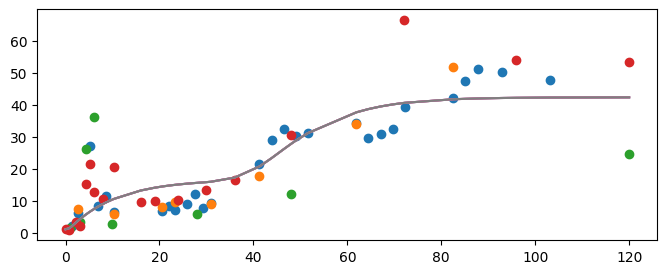

In [6]:
gene = "ENSDARG00000052775" # 0.1
#gene = "ENSDARG00000112667" # 0.15
#gene = "ENSDARG00000043976" # 0.2
#gene = "ENSDARG00000037284" # 0.25
gene = "ENSDARG00000102572" # 0.3

data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(ensembl_gene_id = gene)
fit = xr.load_dataset("results/results_summary/Rep_M/simulation_results.nc").sel(ensembl_gene_id = gene)

plt.figure(figsize=(8,3))
plt.plot(data.time, data.tpm, "o")
plt.plot(fit.time, fit.y, )
plt.show()

In [7]:
#non_div = res[res["n_divergences"]>0].sort_values("gene_id").gene_id.unique()
non_conv = res[(res["ess_bulk_min"] < ESS_thresh) & (res["n_divergences"] > 0) ].sort_values("gene_id").gene_id.unique()
print(non_conv.size)

non_conv = res[res["status"] == "non_converged"].sort_values("gene_id").gene_id.unique()
print(non_conv.size)

non_conv = res[(res["rhat_max"] >1.1) & (res["model"] == "Rep_M")].sort_values("gene_id").gene_id.unique()

#non_div.tofile("non_div_genes.txt", "\n")
with open('data/non_conv_genes_m.txt', 'w+') as f:
    f.write("\n".join(non_conv)) 

#res[res["n_divergences"]>0].sort_values("gene_id")
#res[res["rhat_max"] >r_hat_thresh].sort_values("n_divergences")#.value_counts("model")
res[(res["ess_bulk_min"] < ESS_thresh) & (res["n_divergences"] > 0)].sort_values("gene_id")

660
2746


,gene_id,rhat_max,ess_bulk_min,ess_tail_min,convergence_error,n_divergences,frac_divergences,loo,loo_se,p_loo,...,load_error,converged,good_fit_r2,good_pattern,reliable_loo,well_calibrated,status,supercluster,subcluster,model
64244,ENSDARG00000000229,1.59,7.0,9.0,NaN,150,0.018750,-71.023070,10.531371,44.370212,...,NaN,False,False,False,False,False,non_converged,SU,0,Rep_M
42938,ENSDARG00000000568,1.02,151.0,1166.0,NaN,12,0.001500,-41.655774,13.875732,8.541972,...,NaN,False,False,False,False,True,non_converged,SD,0,Rep_M
42917,ENSDARG00000000853,1.05,139.0,56.0,NaN,27,0.003375,-16.140401,11.129016,8.419170,...,NaN,False,True,True,False,True,non_converged,SD,0,Rep_M
60156,ENSDARG00000001470,1.59,7.0,4.0,NaN,27,0.003375,-89.217288,7.490351,34.957731,...,NaN,False,False,False,False,True,non_converged,SD,2,Rep_M
43032,ENSDARG00000002128,1.13,20.0,10.0,NaN,4,0.000500,20.469582,9.039139,10.058137,...,NaN,False,True,True,False,True,non_converged,DSD,1,Rep_M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64010,ENSDARG00000116932,1.01,356.0,100.0,NaN,4,0.000500,-37.517196,8.970420,6.227035,...,NaN,False,True,True,False,True,non_converged,DSU,2,Rep_M
42666,ENSDARG00000117308,1.03,222.0,159.0,NaN,3,0.000375,36.611003,6.676001,6.885895,...,NaN,False,True,False,False,True,non_converged,DSU,2,Rep_Z
64113,ENSDARG00000117308,1.05,72.0,182.0,NaN,24,0.003000,36.535203,6.413348,6.195143,...,NaN,False,True,False,False,True,non_converged,DSU,2,Rep_M
64177,ENSDARG00000117538,1.03,142.0,104.0,NaN,2,0.000250,-43.325236,8.501375,13.103333,...,NaN,False,False,True,False,True,non_converged,DSD,0,Rep_M


<Axes: title={'center': 'GOF summary by model (n = 21,440 genes)'}, xlabel='Proportion of genes'>

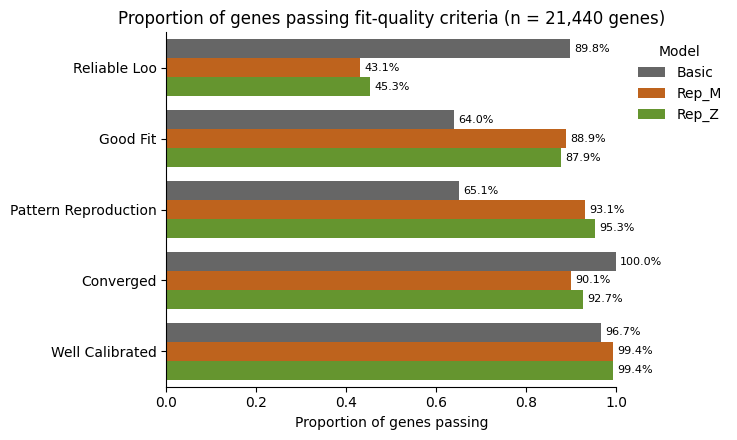

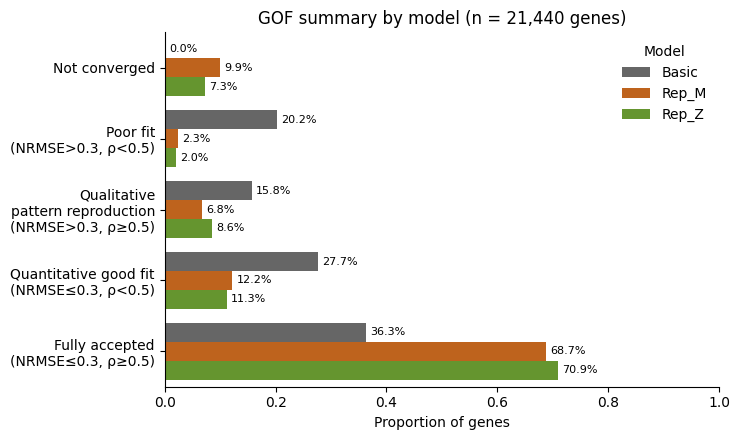

In [4]:
from plots.plot_scorecard_summary import *
res_plot = res_joined.reset_index()
plot_pass_rates(res_plot, hue="model")
plot_status_breakdown(df=res_plot, status_dict=status_dict, hue="model")

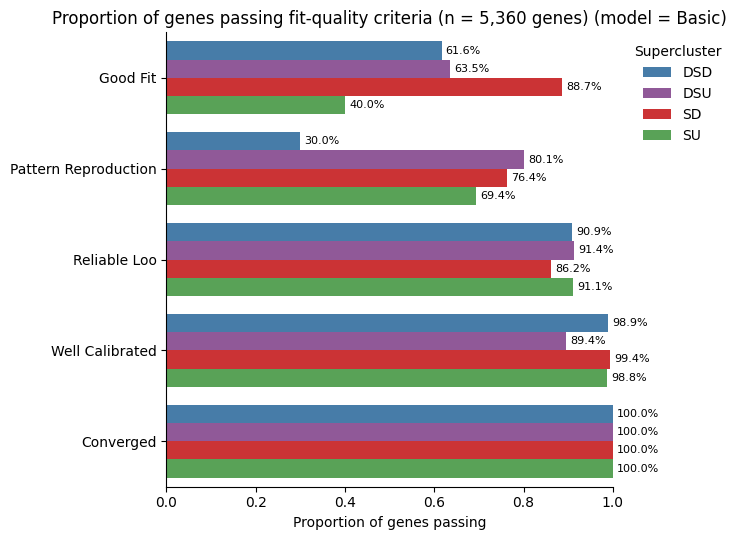

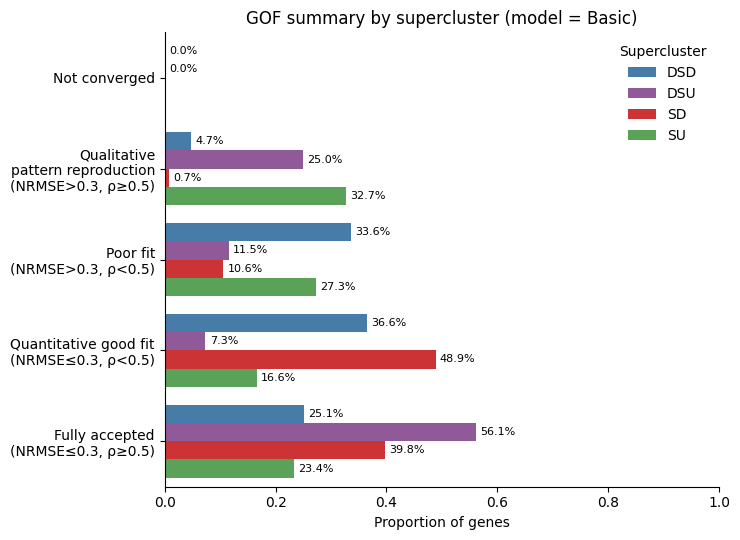

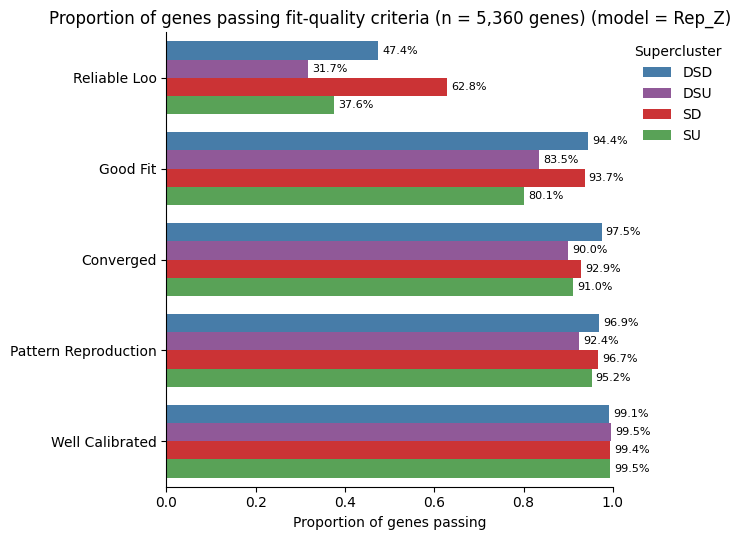

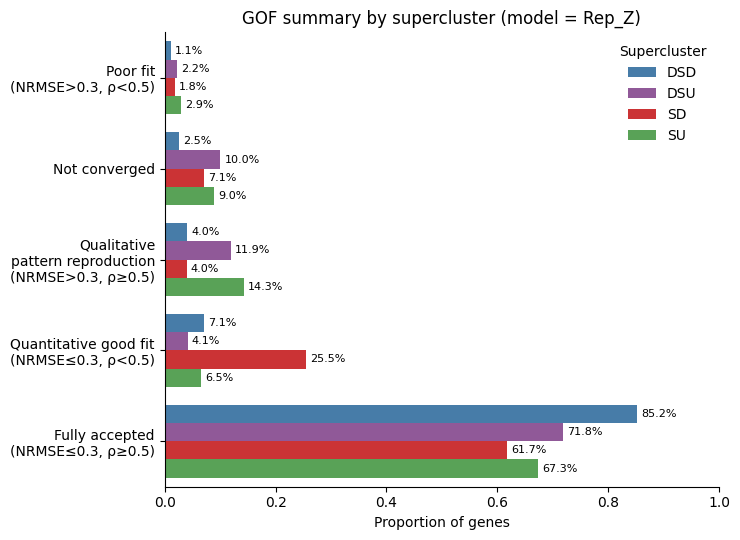

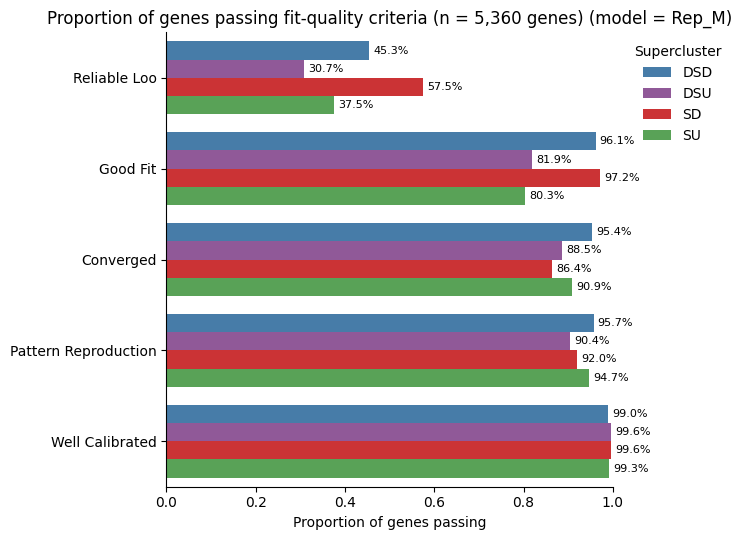

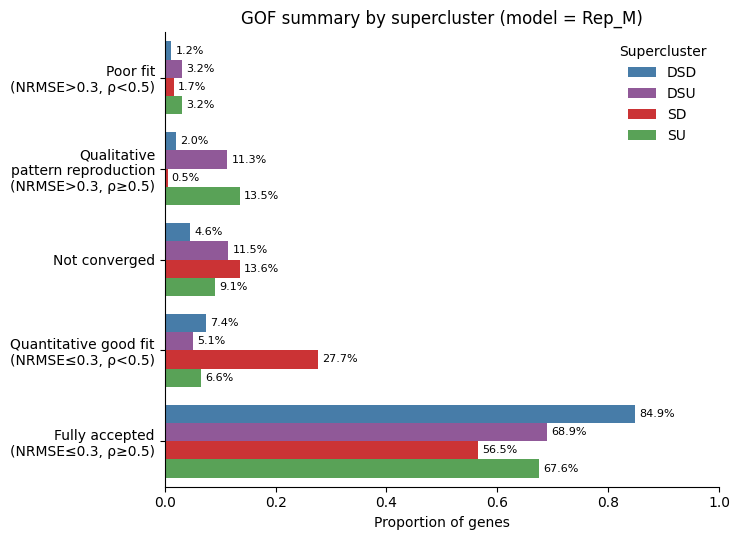

In [84]:
from plots.plot_scorecard_summary import *
res_plot = res_joined.reset_index()

for m in res_plot.model.unique():
    res1 = res_plot[res_plot["model"] == m].copy()
    plot_pass_rates(res1, hue="supercluster", title=m)
    plot_status_breakdown(res1, status_dict=status_dict, hue="supercluster", title=m)

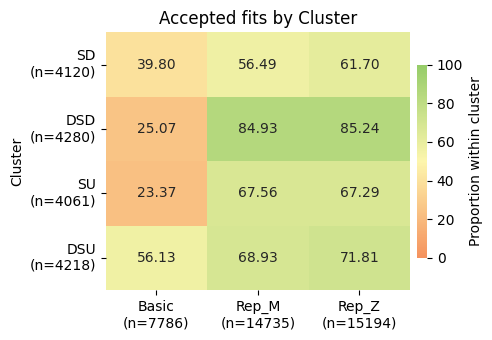

In [ ]:
# accepted fit heatmap

accepted = res_plot[res_plot["status"] == "fully_accepted"][["gene_id", "model", "supercluster", "status"]]

count_model = accepted["model"].value_counts()
count_cluster = accepted.groupby("supercluster")["gene_id"].nunique()

merged_counts = res_plot.groupby(["model", "supercluster"]).size().reset_index(name="merged")
accepted_counts = accepted.groupby(["model", "supercluster"]).size().reset_index(name="accepted")
result = pd.merge(merged_counts, accepted_counts, how="left", on=["model", "supercluster"])

result["accepted"] = result["accepted"].fillna(0).astype(int)
result["ratio"] = result["accepted"] / result["merged"] * 100

# Pivot for heatmap
pivot = result.pivot(index="supercluster", columns="model", values="ratio") 
pivot = pivot.reindex(index=cluster_order, columns=model_order)

fig, ax = plt.subplots(figsize=(5,3.5))
sns.heatmap(pivot, vmin=0, vmax=100, annot=True, fmt=".2f", 
            cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': '% within cluster', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)


ax.set_xticklabels([f"{c}\n(n={count_model.get(c, 0)})" for c in pivot.columns])
ax.set_yticklabels([f"{c}\n(n={count_cluster.get(c, 0)})" for c in pivot.index], rotation=0)

ax.set(xlabel="", title=f"Accepted fits by Cluster", ylabel="Cluster")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"results/figures/accepted_heatmap_gof.png", dpi=300)
plt.show()

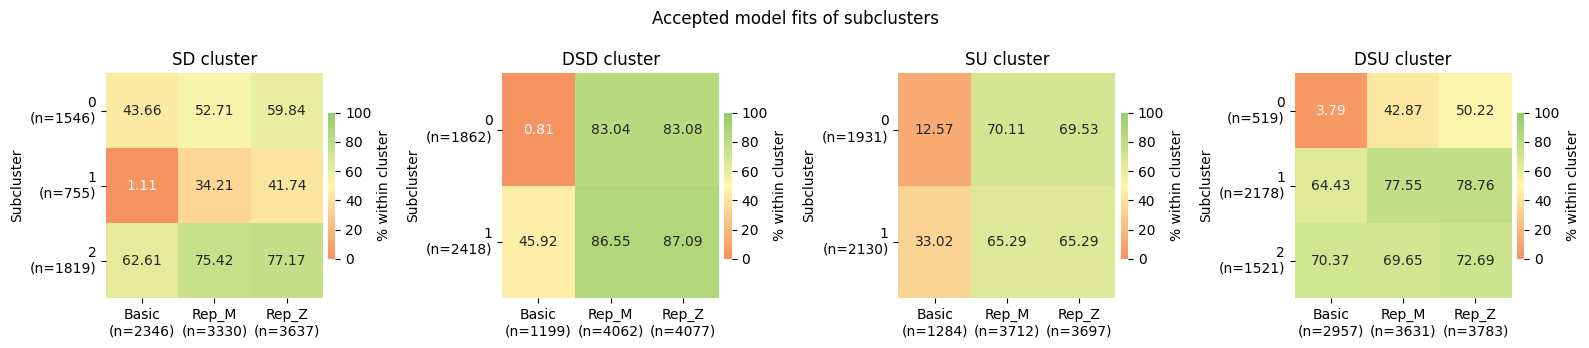

In [102]:
# accepted fit heatmap per subcluster
plot = res_joined.copy()

fig, ax = plt.subplots(1,4, figsize=(16,3.5), sharey=False)

for x, i in enumerate(cluster_order):

    d = plot[plot["supercluster"] == i]

    accepted = d[d["status"] == "fully_accepted"][["gene_id", "model", "supercluster", "subcluster", "status"]]

    count_model = accepted["model"].value_counts()
    count_cluster = accepted.groupby("subcluster")["gene_id"].nunique()

    merged_counts = d.groupby(["model", "subcluster"]).size().reset_index(name="merged")
    accepted_counts = accepted.groupby(["model", "subcluster"]).size().reset_index(name="accepted")
    result = pd.merge(merged_counts, accepted_counts, how="left", on=["model", "subcluster"])

    result["accepted"] = result["accepted"].fillna(0).astype(int)
    result["ratio"] = result["accepted"] / result["merged"] * 100

    # Pivot for heatmap
    pivot = result.pivot(index="subcluster", columns="model", values="ratio") 
    pivot = pivot.reindex(columns=model_order)

    sns.heatmap(pivot, vmin=0, vmax=100, annot=True, fmt=".2f", 
                cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
                cbar_kws={'label': '% within cluster', 'shrink': 0.65, 'pad': 0.02 }, alpha=0.8, ax=ax[x] )

    ax[x].set_xticklabels([f"{c}\n(n={count_model.get(c, 0)})" for c in pivot.columns])
    ax[x].set_yticklabels([f"{c}\n(n={count_cluster.get(c, 0)})" for c in pivot.index], rotation=0)

    ax[x].set(xlabel="", title=f"{i} cluster", ylabel="Subcluster")
    plt.yticks(rotation=0)

plt.suptitle("Accepted model fits of subclusters")
plt.tight_layout()
plt.savefig(f"results/figures/accepted_heatmap_gof_subcluster.png", dpi=300)
plt.show()

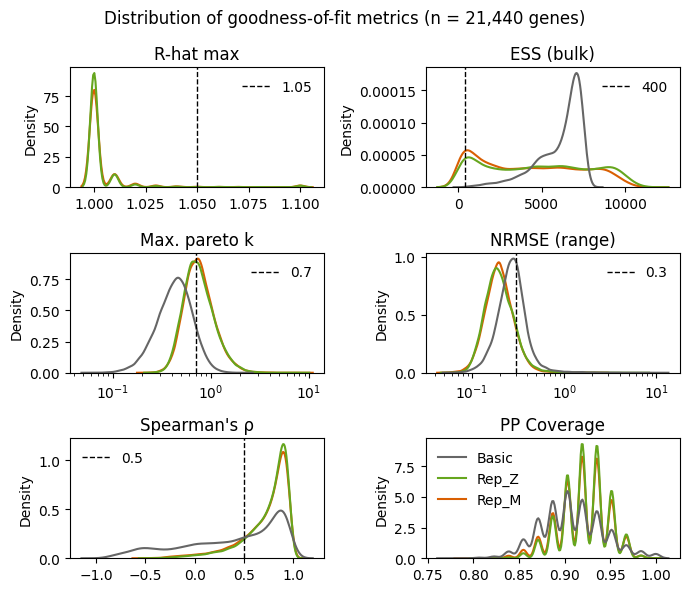

In [7]:
# GOF distribution: all model fits
d = res_joined.reset_index()  #[(res["nrmse_mean"] < 100) & (res["r2"] > 0.1)].copy()
d1 = res[res["model"] != "Basic"].copy()
#d1 = d1[d1["rhat_max"] < 1.05]
d1["rhat_max"] = d1["rhat_max"].clip(upper=1.1)
genes = d.gene_id.nunique()

fig, ax = plt.subplots(3,2, figsize=(7, 6))
ax = ax.flatten()

metrics=["R-hat max", "ESS (bulk)", "Max. pareto k", 
         "NRMSE (range)", "Spearman's ρ","PP Coverage", ]

args = {"log_scale": True, "hue": "model", "palette": mod_color_dict, "legend": False,}

args0 = args.copy()
args0["legend"] = True

args1 = args.copy()
args1["log_scale"] = False

args2 = args1.copy()
args2["legend"] = True

sns.kdeplot(data=d1, x="rhat_max", **args2,  ax=ax[0],)
sns.kdeplot(data=d, x="ess_bulk_min", **args2,  ax=ax[1],)
sns.kdeplot(data=d, x="max_pareto_k", ax=ax[2], **args)
ax[0].axvline(r_hat_thresh, color="black", ls="--", lw=1, label=r_hat_thresh)
ax[1].axvline(ESS_thresh, color="black", ls="--", lw=1, label=ESS_thresh)
ax[2].axvline(r2_thresh, color="black", ls="--", lw=1, label=r2_thresh)

sns.kdeplot(data=d, x="NRMSE",ax=ax[3],**args0, cumulative=False)
sns.kdeplot(data=d, x="spearman_rho", ax=ax[4], **args1, cumulative=False)
#sns.kdeplot(data=d, x="pp_coverage_50", **args2, ax=ax[5], ls="--")
sns.kdeplot(data=d, x="pp_coverage_90", **args2,  ax=ax[5], )

ax[3].axvline(NRMSE_thresh, color="black", ls="--", lw=1, label=NRMSE_thresh)
ax[4].axvline(rho_tresh, color="black", ls="--", lw=1, label=rho_tresh)

sns.move_legend(ax[5], loc="upper left", frameon=False, title="")
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
ax[3].legend(frameon=False)
ax[4].legend(frameon=False)

for i in range(len(metrics)):
    ax[i].set(title=metrics[i], xlabel="")

plt.suptitle(f"Distribution of goodness-of-fit metrics (n = {int(genes):,} genes)", fontsize=12)
plt.tight_layout()
plt.savefig(f"figures/gof_distribution.png", dpi=300)

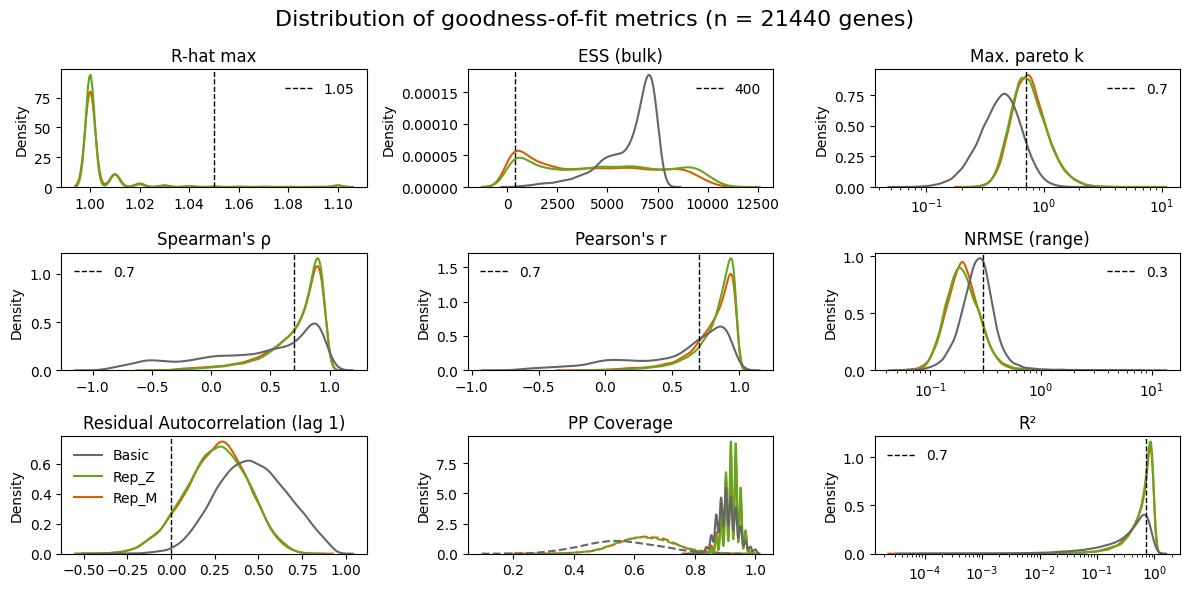

In [76]:
# GOF distribution: all model fits
d = res_joined.reset_index()  #[(res["nrmse_mean"] < 100) & (res["r2"] > 0.1)].copy()
d1 = res[res["model"] != "Basic"].copy()
#d1 = d1[d1["rhat_max"] < 1.05]
d1["rhat_max"] = d1["rhat_max"].clip(upper=1.1)
genes = d.gene_id.nunique()

fig, ax = plt.subplots(3,3, figsize=(12, 6))
ax = ax.flatten()

metrics=["R-hat max", "ESS (bulk)", "Max. pareto k", 
         "Spearman's ρ", "Pearson's r", "NRMSE (range)", 
         #"PMF Coverage 95%", 
         "Residual Autocorrelation (lag 1)",
         "PP Coverage", "R²", ]

args = {"log_scale": True, "hue": "model", "palette": mod_color_dict, "legend": False,}

args0 = args.copy()
args0["legend"] = True

args1 = args.copy()
args1["log_scale"] = False

args2 = args1.copy()
args2["legend"] = True

sns.kdeplot(data=d1, x="rhat_max", **args2,  ax=ax[0],)
sns.kdeplot(data=d, x="ess_bulk_min", **args2,  ax=ax[1],)
sns.kdeplot(data=d, x="max_pareto_k", ax=ax[2], **args)
ax[0].axvline(r_hat_thresh, color="black", ls="--", lw=1, label=r_hat_thresh)
ax[1].axvline(ESS_thresh, color="black", ls="--", lw=1, label=ESS_thresh)
ax[2].axvline(r2_thresh, color="black", ls="--", lw=1, label=r2_thresh)

sns.kdeplot(data=d, x="spearman_rho", ax=ax[3], **args1, cumulative=False)
sns.kdeplot(data=d, x="pearson_r", ax=ax[4], **args1, cumulative=False)
sns.kdeplot(data=d, x="NRMSE",ax=ax[5],**args0, cumulative=False)
ax[3].axvline(0.7, color="black", ls="--", lw=1, label=rho_tresh)
ax[4].axvline(0.7, color="black", ls="--", lw=1, label=rho_tresh)
ax[5].axvline(NRMSE_thresh, color="black", ls="--", lw=1, label=NRMSE_thresh)

sns.kdeplot(data=d, x="resid_autocorr_lag1", **args2, ax=ax[6])
ax[6].axvline(0, color="black", ls="--", lw=1, label="Optimum (0.0)")
#sns.kdeplot(data=d, x="pmf_coverage_95", ax=ax[6], **args2)
sns.kdeplot(data=d, x="pp_coverage_50", **args1, ax=ax[7], ls="--")
sns.kdeplot(data=d, x="pp_coverage_90", **args1,  ax=ax[7],)
sns.kdeplot(data=d, x="r2",ax=ax[8], **args)
ax[8].axvline(r2_thresh, color="black", ls="--", lw=1, label=r2_thresh)

sns.move_legend(ax[6], loc="upper left", frameon=False, title="")
ax[3].legend(frameon=False)
ax[4].legend(frameon=False)
ax[5].legend(frameon=False)
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[2].legend(frameon=False)
ax[8].legend(frameon=False)

for i in range(len(metrics)):
    ax[i].set(title=metrics[i], xlabel="")

plt.suptitle(f"Distribution of goodness-of-fit metrics (n = {genes} genes)", fontsize=16)
plt.tight_layout()
plt.savefig(f"figures/gof_distribution.png", dpi=300)

### Determine Noise level of dataset


In [ ]:
tpm = pd.read_csv("data/White_Pauli_JN_BK/tpms_white_pauli_JN_BK.csv")
samples = pd.read_csv("data/White_Pauli_JN_BK/samples_white_pauli_JN_BK.csv")

meta = tpm[["ensembl_gene_id","ensembl_transcript_id","transcript_length","transcript_is_canonical","external_gene_name"]]
meta.to_csv("data/meta_data.csv", index=False)

tpm_long = tpm.melt(
    id_vars=["ensembl_gene_id", "ensembl_transcript_id", "transcript_length"],
    var_name="sample_id",
    value_vars=samples["sample_id"].unique(),
    value_name="tpm_values"
    )
#Merge with metadata
combined_df = tpm_long.merge(samples, on="sample_id", how="left")
combined_df.head()

agg = combined_df.groupby(["source", "time_hpf_standard", "ensembl_gene_id", "sample_id"])["tpm_values"].sum().reset_index()
agg_mean = (
    agg.groupby(["time_hpf_standard", "ensembl_gene_id", "source"], observed=True)
    .agg(tpm=("tpm_values", "mean"),))

dataset = agg_mean.to_xarray().rename({"time_hpf_standard": "time"}) 
dataset = dataset.assign_attrs(
    description="RNA-seq data from multiple sources: White et al. (2017), Pauli et al. (2011), BK, JN.",
    units="TPM")
dataset

<xarray.Dataset>
Dimensions:          (time: 5, ensembl_gene_id: 5, source: 4)
Coordinates:
  * time             (time) float64 0.0 0.75 0.875 1.29 2.25
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * source           (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 66.61
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

In [ ]:
ds_BK = dataset.sel(source="BK").dropna(dim="time")
ds_JN = dataset.sel(source="JN").dropna(dim="time")
ds_P = dataset.sel(source="Pauli et al.").dropna(dim="time")
ds_W = dataset.sel(source="White et al.").dropna(dim="time")

In [33]:
# check number of replicates per sample
rep_counts = (agg.groupby(["source", "time_hpf_standard"])["sample_id"].nunique().reset_index(name="n_replicates"))
rep_counts.pivot(index="time_hpf_standard", columns="source", values="n_replicates")

rep_counts_1 = (agg.groupby(["time_hpf_standard"])["sample_id"].nunique().reset_index(name="n_replicates"))
rep_counts[rep_counts["n_replicates"] >= 2].value_counts("source")

source
BK              20
White et al.    18
JN               8
Pauli et al.     8
Name: count, dtype: int64

In [ ]:
agg_stats = (
    agg.groupby(["time_hpf_standard", "ensembl_gene_id", "source"], observed=True)
    .agg(
        tpm=("tpm_values", "mean"),
        tpm_range=("tpm_values", lambda x: x.max() - x.min()),
        tpm_std=("tpm_values", "std"),          # sample std, ddof=1
        n_reps=("tpm_values", "count"),
        tpm_rmse=("tpm_values", lambda x: np.sqrt(np.mean((x - x.mean())**2))),  # population RMSE
    )
)

agg_stats["tpm_cv"] = agg_stats["tpm_std"] / agg_stats["tpm"]
agg_stats["tpm_nrmse"] = agg_stats["tpm_rmse"] / agg_stats["tpm_range"]
agg_stats
ds = agg_stats.to_xarray()
ds

tpm  tpm_range  \
time_hpf_standard ensembl_gene_id    source                                
0.0               ENSDARG00000000001 White et al.    2.212666   2.354600   
                  ENSDARG00000000002 White et al.    0.277271   0.279675   
                  ENSDARG00000000018 White et al.    5.205196   2.710530   
                  ENSDARG00000000019 White et al.  110.508720  23.376400   
                  ENSDARG00000000068 White et al.   21.300924   6.818000   
...                                                       ...        ...   
120.0             ENSDARG00000117825 White et al.    0.000000   0.000000   
                  ENSDARG00000117826 Pauli et al.    0.083503   0.167007   
                                     White et al.    0.000000   0.000000   
                  ENSDARG00000117827 Pauli et al.    0.072637   0.041611   
                                     White et al.    0.000000   0.000000   

                                                    tpm_std  n_reps  tpm_rmse  \
time_hpf_standard ensembl_gene_id    source                                     
0.0               ENSDARG00000000001 White et al.  0.889821       5  0.795880   
                  ENSDARG00000000002 White et al.  0.128519       5  0.114951   
                  ENSDARG00000000018 White et al.  1.151373       5  1.029819   
                  ENSDARG00000000019 White et al.  9.393754       5  8.402029   
                  ENSDARG00000000068 White et al.  2.589666       5  2.316268   
...                                                     ...     ...       ...   
120.0             ENSDARG00000117825 White et al.  0.000000       5  0.000000   
                  ENSDARG00000117826 Pauli et al.  0.118092       2  0.083503   
                                     White et al.  0.000000       5  0.000000   
                  ENSDARG00000117827 Pauli et al.  0.029423       2  0.020805   
                                     White et al.  0.000000       5  0.000000   

                                                     tpm_cv  tpm_nrmse  
time_hpf_standard ensembl_gene_id    source                             
0.0               ENSDARG00000000001 White et al.  0.402149   0.338011  
                  ENSDARG00000000002 White et al.  0.463513   0.411015  
                  ENSDARG00000000018 White et al.  0.221197   0.379933  
                  ENSDARG00000000019 White et al.  0.085005   0.359424  
                  ENSDARG00000000068 White et al.  0.121575   0.339728  
...                                                     ...        ...  
120.0             ENSDARG00000117825 White et al.       NaN        NaN  
                  ENSDARG00000117826 Pauli et al.  1.414214   0.500000  
                                     White et al.       NaN        NaN  
                  ENSDARG00000117827 Pauli et al.  0.405072   0.500000  
                                     White et al.       NaN        NaN  

[2267340 rows x 7 columns]

In [37]:
ds = agg_stats.to_xarray()
ds

common_mask = (ds['n_reps'] >= 2)  # drop n=1,2 timepoints where CV is undefined or unstable
filtered = ds['tpm_nrmse'].where(common_mask)

x = filtered.mean(dim='time_hpf_standard', skipna=True).median(dim='ensembl_gene_id')
x

<xarray.DataArray 'tpm_nrmse' (source: 4)>
array([0.3826749 , 0.41400207, 0.49129453, 0.37320373])
Coordinates:
  * source   (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'

In [40]:
(x.values * [3, 2, 1, 3]).sum() / 9

0.3985482867190507

In [41]:
(ds['n_reps'].mean(dim="ensembl_gene_id") > 2).sum()
#ds['n_reps'].mean(dim="ensembl_gene_id").max()

<xarray.DataArray 'n_reps' ()>
array(44)

In [ ]:
dataset = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
tpm_data = dataset['tpm'].values  # Shape: (time, genes, sources)
# Count non-NaN values across all genes and sources for each time point
# axis=(1, 2) means sum over ensembl_gene_id and source dimensions
non_nan_counts = np.sum(~np.isnan(tpm_data), axis=(2)).mean(axis=1)
# Count time points where more than one non-NaN value exists
time_points_with_multiple = np.sum(non_nan_counts > 1)
time_points_with_multiple

12

In [ ]:
dataset = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
dataset = dataset.sel(time = (non_nan_counts > 1))
data_mean = dataset.mean(dim="source")
data_std = dataset.std(dim="source")
cv = data_std / data_mean
cv.mean(dim='time', skipna=True).median(dim='ensembl_gene_id')

<xarray.Dataset>
Dimensions:  ()
Data variables:
    tpm      float64 0.1986

## Cluster GOF

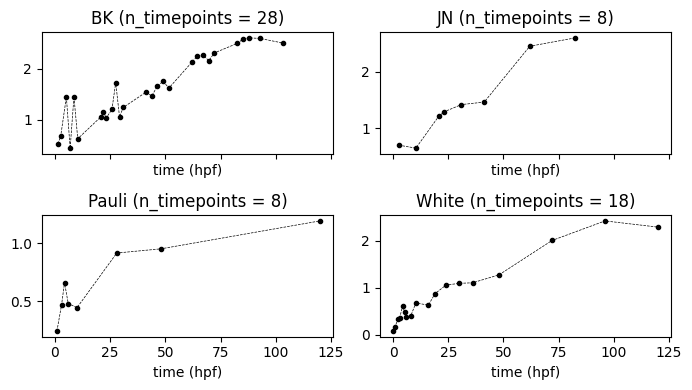

In [6]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")

# t_not = [5.16, 8.6, 27.52, 41.28]
# mask = ~ds0.time.isin(t_not)
# ds0 = ds0.sel(time=mask)

fig, ax = plt.subplots(2,2, figsize=(7, 4), sharex=True)
ax = ax.flatten()

for x, src in enumerate(ds0.source.values):
    ds = ds0.sel(source=src)
    ds = ds.dropna(dim="time", how="all", subset=["tpm"])
    #print(np.isnan(ds["tpm"].values).sum())
    ax[x].plot(ds.time, ds.tpm.median(dim="ensembl_gene_id"), ".--", c="k", lw=0.5)
    ax[x].set(title=f"{src} (n_timepoints = {len(ds.time)})", xlabel="time (hpf)")
plt.tight_layout()

In [7]:
import pandas as pd
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 120))
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 1).all(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time", "source"))) / ds.tpm.std(dim=("time", "source"))

ds_filtered = ds.sel(ensembl_gene_id=mask)

traj120 = xr.load_dataarray(f"clustering/results/{sc}_gene_trajectories_120.nc")
gof120 = pd.read_csv("clustering/results/gof_trajectories_120.csv")
print("n genes: ",(gof120.ensembl_gene_id.nunique()))
gof120.accepted.sum()

gene_sums = gof120.groupby("ensembl_gene_id").sum("accepted")
accepted_genes = gene_sums[gene_sums["accepted"] > 0].index.to_list()
rejected_genes = gene_sums[gene_sums["accepted"] == 0].index.to_list()
print("accepted_genes",len(accepted_genes))
print("rejected_genes", len(rejected_genes))

ds_filtered = ds.sel(ensembl_gene_id=accepted_genes)
ds_filtered

n genes:  23428
accepted_genes 21440
rejected_genes 1988


<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 21440, time: 50, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 0.6855
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

In [45]:
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc")
genes = labels.ensembl_gene_id.values
genes.sort()
print(len(genes))

21440


In [46]:
gof120[["nrmse", "pearson", "spearman"]].describe()

,nrmse,pearson,spearman
count,23428.000000,23428.000000,23428.000000
mean,0.122417,0.822520,0.777490
std,0.043547,0.181587,0.186189
min,0.024408,-0.112481,-0.213802
25%,0.090610,0.769369,0.703362
50%,0.115410,0.891443,0.839970
75%,0.148667,0.948373,0.911150
max,0.368997,0.997841,0.993149


Median NRMSE:  0.11541028708213791
Median Pearson:  0.8914431347057952
Median Spearman:  0.8399697866967577


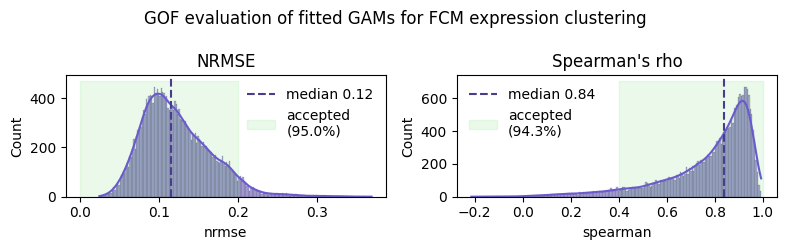

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))

palette = {"avg": "slateblue"}

# med_nrmse = gof120.groupby("source").nrmse.median().item()
# med_pearson = gof120.groupby("source").pearson.median().item()
# med_spearman = gof120.groupby("source").spearman.median().item()

med_nrmse = gof120.nrmse.median().item()
med_pearson = gof120.pearson.median().item()
med_spearman = gof120.spearman.median().item()

acc_rho = len(gof120[gof120["spearman"] > 0.4]) / len(gof120) * 100
acc_nrmse = len(gof120[gof120["nrmse"] < 0.2]) / len(gof120) * 100

sns.histplot(gof120, x="spearman", log_scale=False, kde=True, ax=ax[1], bins=200,  legend=True,  color="slateblue")
sns.histplot(gof120, x="nrmse",  log_scale=False, kde=True, ax=ax[0], bins=200,  legend=False,  color="slateblue")

ax[1].axvline(x=med_spearman, c="darkslateblue", ls="--", label=f"median {med_spearman:.2f}")
ax[0].axvline(x=med_nrmse, c="darkslateblue", ls="--", label=f"median {med_nrmse:.2f}")
ax[1].fill_betweenx(y=ax[1].get_ylim(), x1=0.4, x2=1.0, alpha=0.1, color="limegreen", label=f"accepted\n({acc_rho:.1f}%)")
ax[0].fill_betweenx(y=ax[0].get_ylim(), x1=0.0, x2=0.2, alpha=0.1, color="limegreen", label=f"accepted\n({acc_nrmse:.1f}%)")

ax[1].set(title="Spearman's rho", )
ax[0].set(title="NRMSE", )
ax[1].legend(frameon=False)
ax[0].legend(frameon=False)

plt.suptitle("GOF evaluation of fitted GAMs for FCM expression clustering")
plt.tight_layout()
plt.savefig("clustering/figs/gof_eval_gams.png", dpi=300)

print("Median NRMSE: ", med_nrmse)
print("Median Pearson: ",med_pearson )
print("Median Spearman: ", med_spearman)

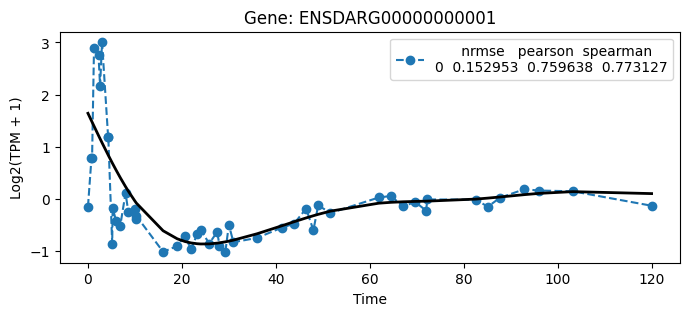

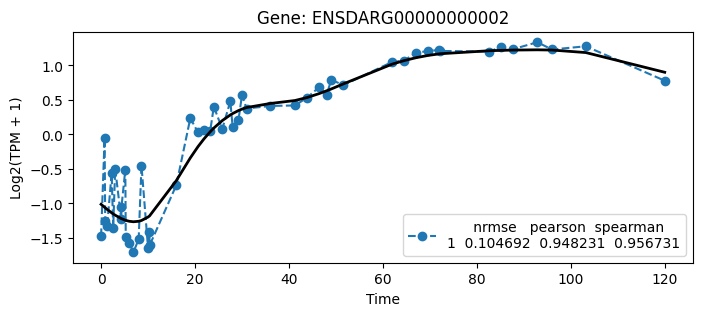

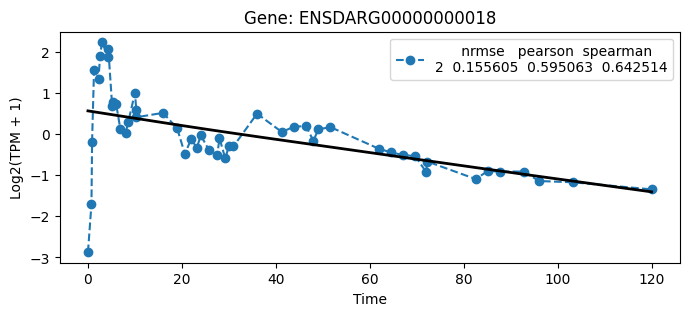

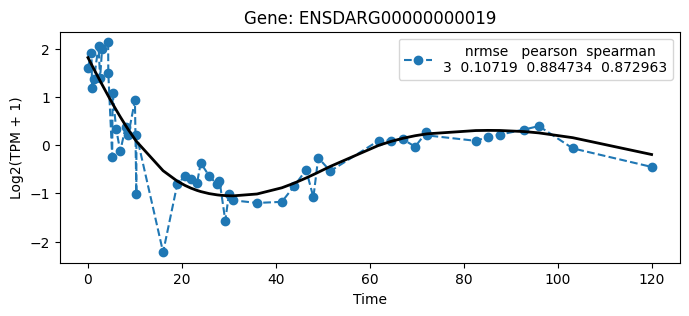

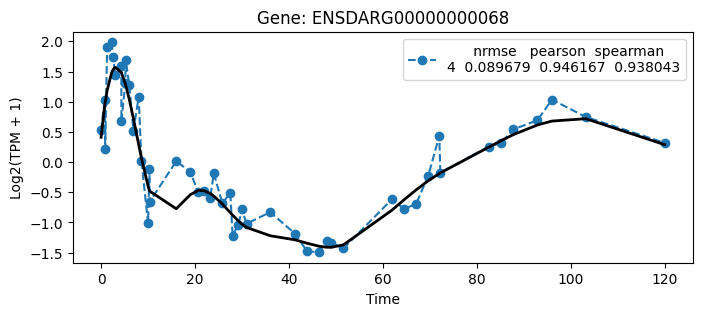

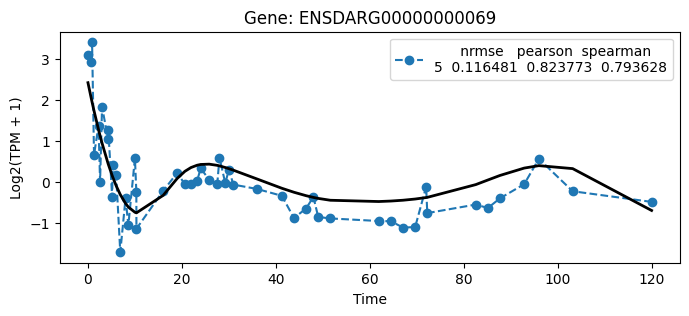

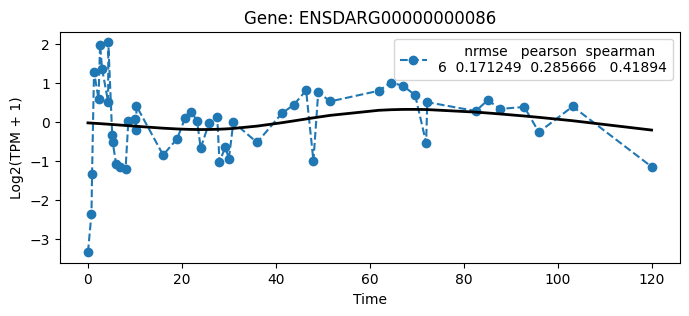

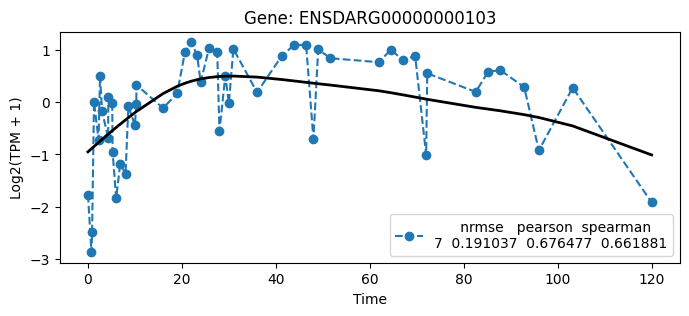

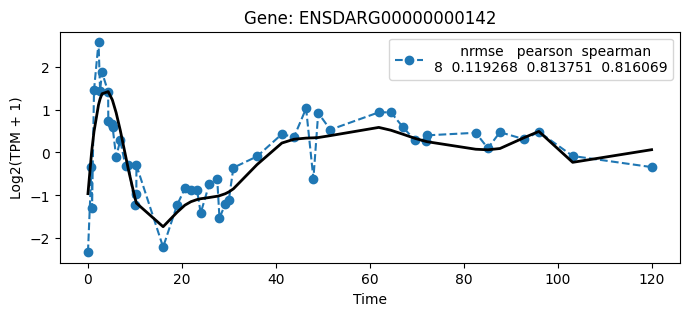

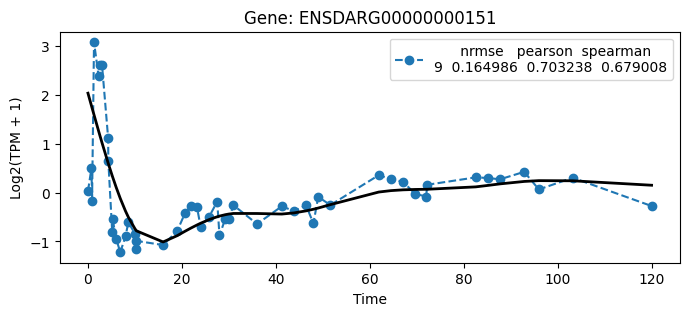

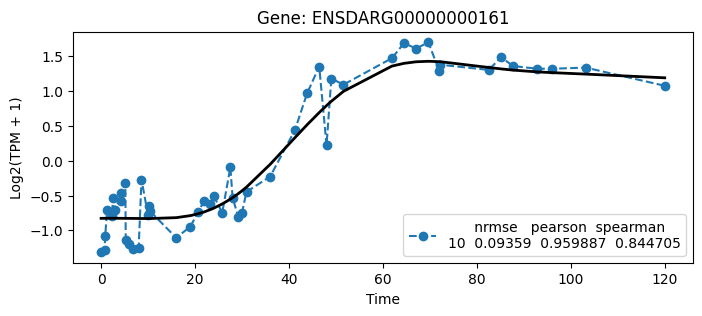

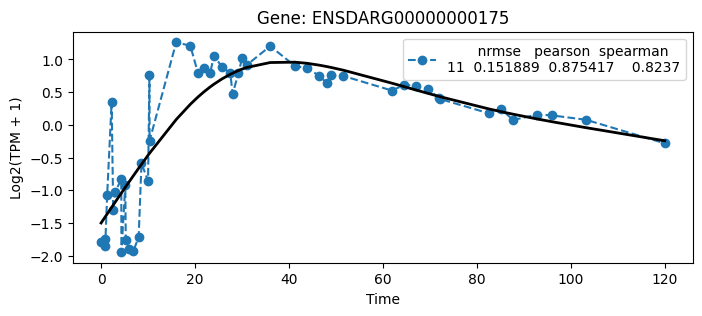

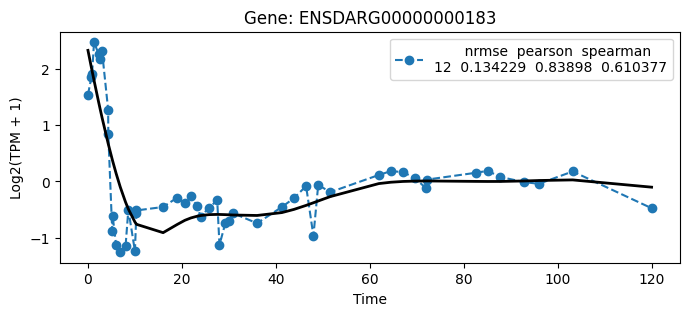

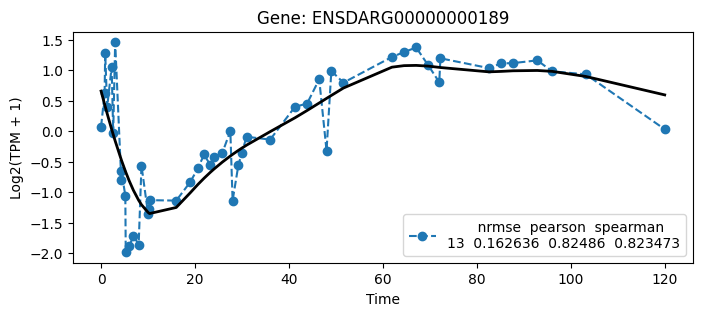

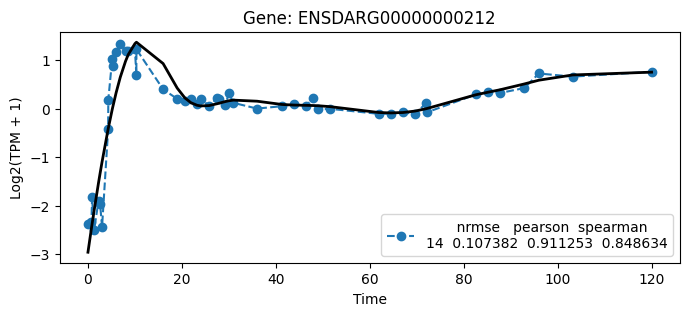

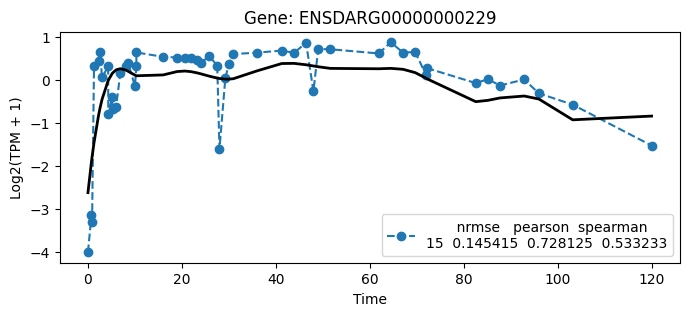

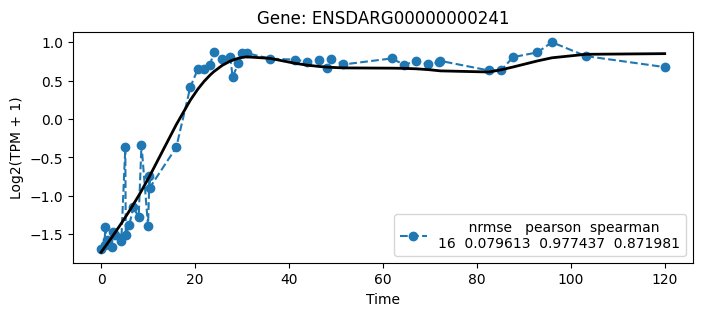

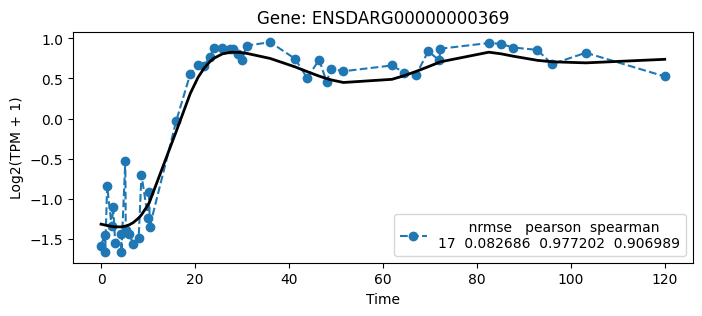

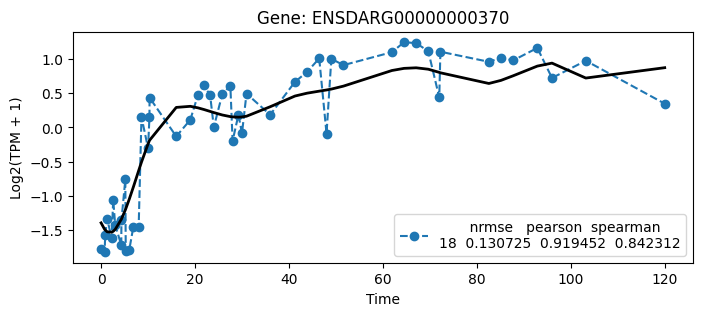

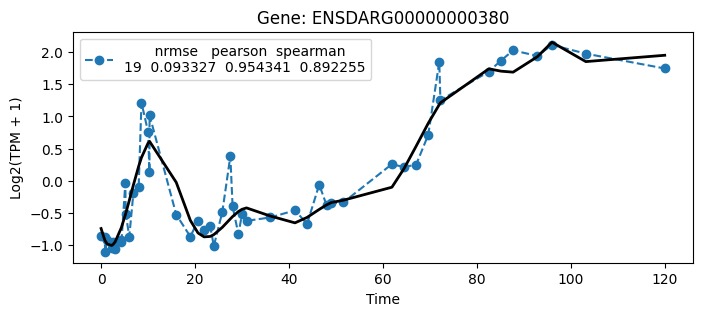

In [48]:
ds_filtered = ds.sel(ensembl_gene_id=accepted_genes)
src = ds.source.values

for g in accepted_genes[0:20]:
#for g in rejected_genes[0:20]:
    y_true = ds_filtered.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj120.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8, 3))
    plt.plot(ds_filtered.time, y_true.mean(dim="source"), marker="o", ls="--", 
             label=gof120.loc[gof120["ensembl_gene_id"] == g][["nrmse"	,"pearson","spearman"]])
    plt.plot(y_pred.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

### Cluster center GOF

Number of genes in dataset: 21440


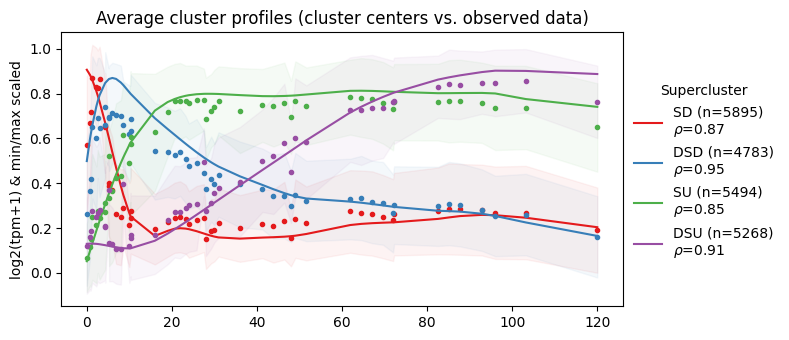

,supercluster,RMSE,r2,spearmanr,pearsonr
0,SD,0.093696,0.848447,0.874286,0.927307
1,DSD,0.107806,0.757196,0.949772,0.961808
2,SU,0.057745,0.944763,0.847587,0.982197
3,DSU,0.086117,0.913892,0.914622,0.970176


In [9]:
def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    rmse = np.sqrt(np.mean((a[mask] - b[mask])**2)).item()
    return rmse

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

from scipy.stats import spearmanr, pearsonr

fuzzy_cntr = xr.load_dataarray(f"clustering/results/{sc}_superclusters_centers.nc")
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)
#ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time", "source"))) / ds.tpm.std(dim=("time", "source")) #z-score
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time"))) / ds.tpm.std(dim=("time")) #z-score

print(f"Number of genes in dataset: {len(labels.ensembl_gene_id)}")

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
colors = sns.color_palette("Set1", 5)

plt.figure(figsize=(8,3.5))
for c in range(fuzzy_cntr.shape[0]):

    gene_ids = labels['ensembl_gene_id'][labels['supercluster'] == c].values

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id"))
    ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id",))
    #ds_c = zscore(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    center = fuzzy_cntr[c, :]

    plt.plot(fuzzy_cntr.time, center, c=colors[c],
             label=f"{cluster_map[c]} (n={ds_c.ensembl_gene_id.size})\n"+r"$\rho$"+f"={spearmanr(center, ds_c_mean)[0]:.2f}", )
    plt.plot(ds_c_mean.time, ds_c_mean, ".", c=colors[c])
    plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":cluster_map[c], "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("clustering/cluster_validation.xlsx")
    
plt.title("Average cluster profiles (cluster centers vs. observed data)")
plt.ylabel("log2(tpm+1) & min/max scaled")
plt.legend(loc=(1.01, 0.15), frameon=False, title="Supercluster")
plt.tight_layout()
plt.savefig("clustering/figs/cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

### Subcluster center GOF

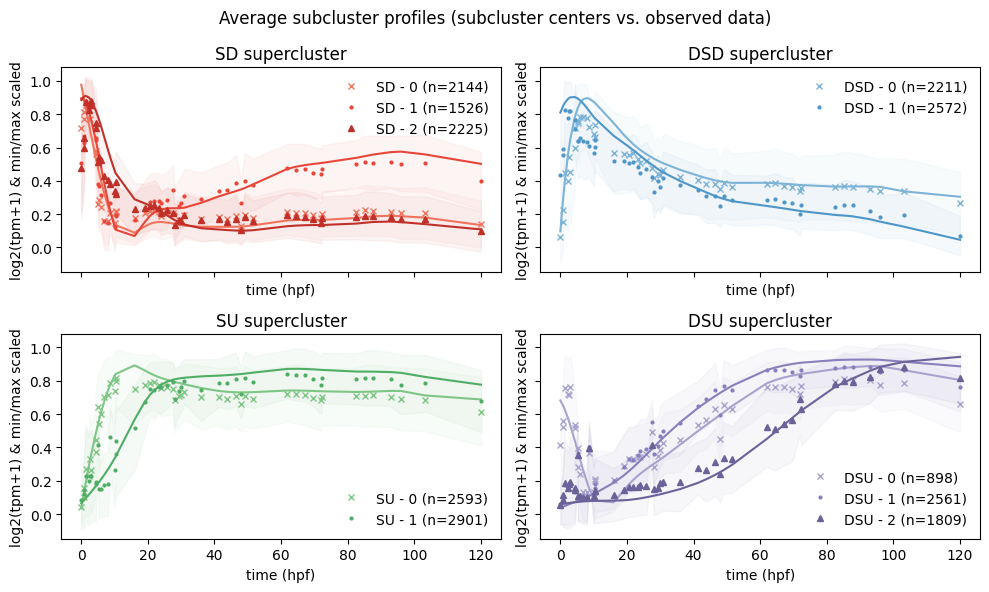

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.084145,0.880437,0.711309,0.940798
1,0,1,0.106449,0.777034,0.895894,0.889161
2,0,2,0.119317,0.843638,0.902617,0.950659
3,1,0,0.090617,0.801805,0.960432,0.966882
4,1,1,0.136513,0.758338,0.970612,0.956267
5,2,0,0.055669,0.928238,0.907611,0.980999
6,2,1,0.071948,0.945565,0.930756,0.978717
7,3,0,0.111564,0.819577,0.916255,0.911587
8,3,1,0.083782,0.940230,0.943529,0.978625
9,3,2,0.095536,0.885405,0.822905,0.965931


In [50]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)

mean = ds.tpm.mean(dim=("time",))
std = ds.tpm.std(dim=("time", ))
ds["tpm"] = (ds.tpm - mean) / std

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
marker_map = {0:"x", 1:".", 2:"^", 3:"s"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 4),
             1:sns.color_palette("Blues_d", 4),
             2:sns.color_palette("Greens_d",4),
             3:sns.color_palette("Purples_d",4),
            }
gof=[]

fig, ax = plt.subplots(2,2, figsize= (10, 6), sharex=True, sharey=True)
ax=ax.flatten()
for k in range(np.unique(labels.supercluster).size):

    #fig, ax = plt.subplots(1,1,figsize= (10, 6), squeeze=False)
    #ax=ax.flatten()
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/{sc}_supercluster_{k}_centers.nc")
    for c in range(fuzzy_cntr.shape[0]):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", ))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", ))

        center = fuzzy_cntr[c, :]

        ax[k].plot(fuzzy_cntr.time, center, c=color_map[k][c])
        ax[k].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=color_map[k][c], 
                   label=f"{cluster_map[k]} - {c} (n={ds_c.ensembl_gene_id.size})", )
        ax[k].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
    ax[k].set(title=f"{cluster_map[k]} supercluster", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
    ax[k].legend(frameon=False)

plt.suptitle("Average subcluster profiles (subcluster centers vs. observed data)")
plt.tight_layout()
plt.savefig(f"clustering/figs/subcluster_validation.png", dpi=300)
plt.show()

pd.DataFrame(gof).to_excel("clustering/subcluster_validation.xlsx")  
pd.DataFrame(gof)

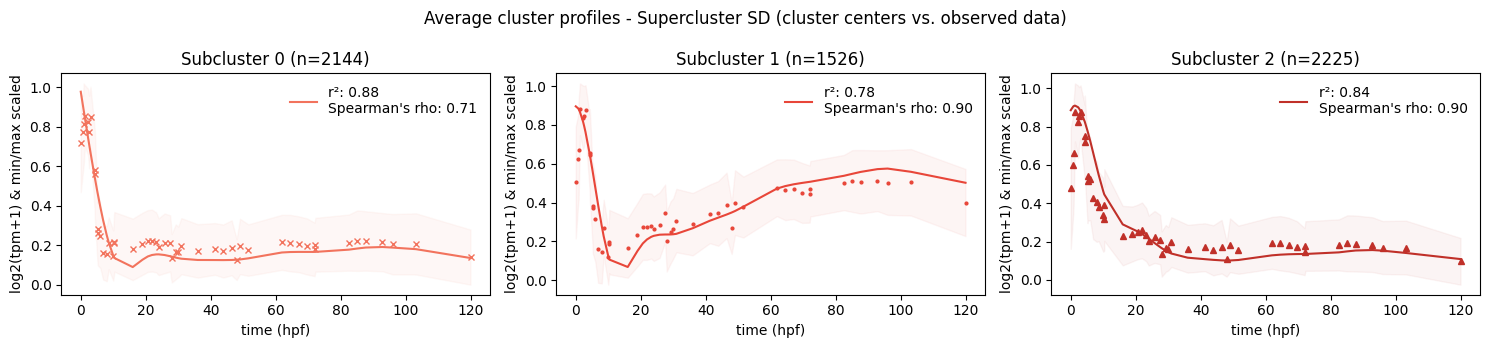

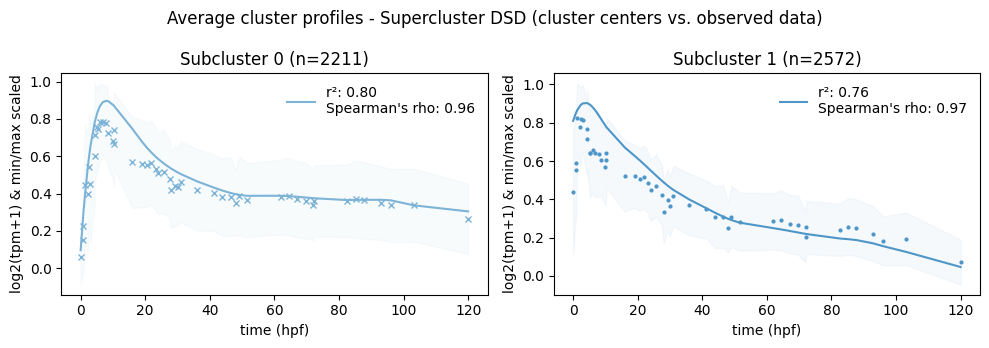

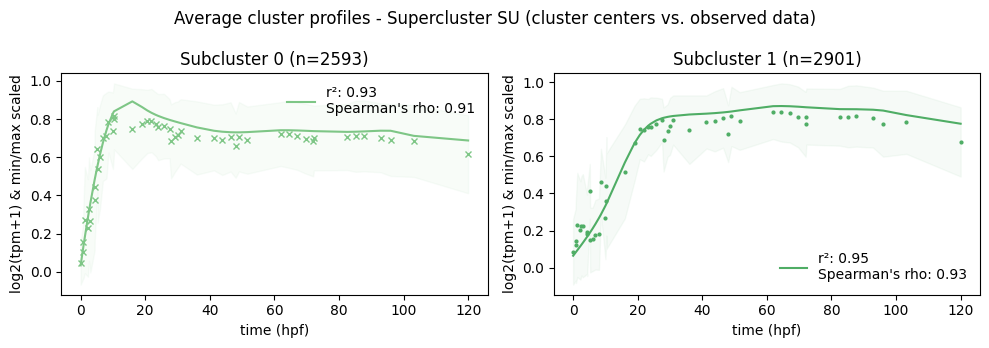

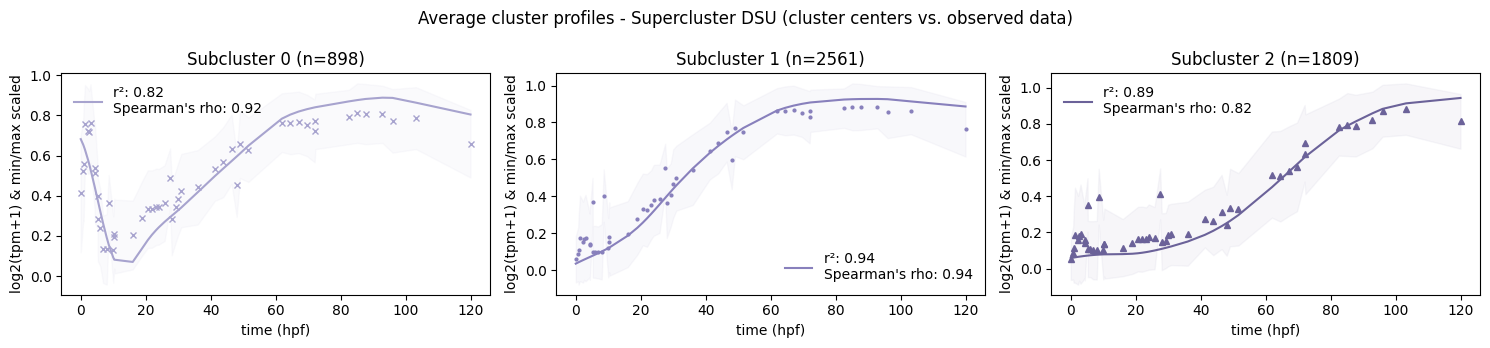

In [51]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").mean(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)

mean = ds.tpm.mean(dim=("time",))
std = ds.tpm.std(dim=("time", ))
ds["tpm"] = (ds.tpm - mean) / std

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
marker_map = {0:"x", 1:".", 2:"^", 3:"s"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 4),
             1:sns.color_palette("Blues_d", 4),
             2:sns.color_palette("Greens_d",4),
             3:sns.color_palette("Purples_d",4),
            }
gof=[]

#fig, ax = plt.subplots(2,2, figsize= (10, 6), sharex=True, sharey=True)
#ax=ax.flatten()
for k in range(4):
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/{sc}_supercluster_{k}_centers.nc")
    sub_cluster = fuzzy_cntr.shape[0]
    fig, ax = plt.subplots(1,sub_cluster, figsize= (5*sub_cluster, 3.5), squeeze=False)
    ax=ax.flatten()

    for c in range(sub_cluster):
        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", ))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", ))

        center = fuzzy_cntr[c, :]

        ax[c].plot(fuzzy_cntr.time, center, 
                   label=f"r²: {r2(center, ds_c_mean):.2f} \nSpearman's rho: {spearmanr(center, ds_c_mean)[0]:.2f}", 
                   c=color_map[k][c])
        ax[c].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=color_map[k][c])
        ax[c].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
        ax[c].set(title=f"Subcluster {c} (n={ds_c.ensembl_gene_id.size})", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
        ax[c].legend(frameon=False)

    plt.suptitle(f"Average cluster profiles - Supercluster {cluster_map[k]} (cluster centers vs. observed data)")
    plt.tight_layout()
    plt.savefig(f"clustering/figs/subcluster_validation_{k}.png", dpi=300)
    plt.show()


## Cluster Heatmap

In [142]:
import seaborn as sns
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_heatmap_supercluster(annotation_path, cluster_col="supercluster", 
                  algo="hierarchical", source="all", norm="minmax", supercluster=None):

    # load annotated dataset (supercluster, subcluster, tpm)
    ann = xr.load_dataset(annotation_path)
    #t_not = [5.16, 8.6, 27.52, 41.28]
    #mask = ~ann.time.isin(t_not)
    #ann = ann.sel(time=mask)

    if supercluster != None:
        ann = ann.where(ann.supercluster == supercluster, drop=True).sel(time=slice(0, 120))

    # select expression data: average over source, or pick one if specified
    if "source" in ann.tpm.dims:
        if source != "all":
            ann = ann.sel(source=source, drop=True)
            ann = ann.dropna(dim="time", how="all", subset=["tpm"])
            tpm = ann.tpm
        else:
            tpm = ann.tpm.mean(dim="source", skipna=True)
    else:
        tpm = ann.tpm

    tpm = tpm.transpose("ensembl_gene_id", "time")

    # drop genes with no valid time points
    valid = np.isfinite(tpm).any(dim="time")
    tpm = tpm.sel(ensembl_gene_id=valid)
    ann = ann.sel(ensembl_gene_id=tpm.ensembl_gene_id)

    # normalise per gene, same scheme as in fuzzy_cmeans
    tpm = np.log2(tpm+1)

    if norm == "minmax":
        X_z = (tpm - tpm.min("time")) / (tpm.max("time") - tpm.min("time"))
    elif norm == "zscore":
        X_z = (tpm - tpm.mean("time")) / tpm.std("time")
        
    elif norm == "meanmax":
        dev = tpm - tpm.mean("time")
        denom = abs(dev).max("time")
        denom = denom.where(denom > 0)
        X_z = dev / denom
    else:
        print("[ERROR] Provide valid normalisation method (minmax, meanmax)")
        return

    still_valid = np.isfinite(X_z).any(dim="time")
    print(f"[debug] genes surviving normalisation: {int(still_valid.sum())} / {still_valid.size}")

    X_z = X_z.sel(ensembl_gene_id=still_valid)
    ann = ann.sel(ensembl_gene_id=X_z.ensembl_gene_id)

    if X_z.sizes["ensembl_gene_id"] == 0:
        raise ValueError(
            f"No genes remain after filtering for source={source!r}. "
            "Check that this source has enough non-NaN time points per gene."
        )

    # cluster labels
    clusters = ann[cluster_col].values

    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time", skipna=True).values

    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]
    centers = (start_idx + end_idx) / 2

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])

    for c, y in zip(unique_clusters, centers):
        ax_bar.text(0.05, y, str(c),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black',
                    transform=ax_bar.transData)

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(expr_plot.values,
                cmap='Spectral_r',
                yticklabels=False, xticklabels=expr_plot.time.values,
                ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02})

    if supercluster != None:
        ax.set_title(f'Gene expression pattern in $D. rerio$ \n Cluster {supercluster}, n={int(still_valid.sum())} ({algo}, {source})', fontsize=12) 
    else:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, {source})', fontsize=12) 

    ax.set(xlabel='time (hpf)', ylabel='')

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(f"clustering/figs/{algo}_cluster_heatmap_{source}_{cluster_col}_{supercluster}.png",
                dpi=300, transparent=True)
    plt.show()

In [143]:
xr.load_dataset("clustering/joint_simulation_results.nc")

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 16184, time: 50)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000002' ... 'ENSDA...
    model            (ensembl_gene_id) object 'M' 'Z' 'Z' 'M' ... 'Z' 'M' 'Z'
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
Data variables:
    M                (ensembl_gene_id, time) float64 0.2773 0.2648 ... 2.331e-10
    Z                (ensembl_gene_id, time) float64 0.0 1.872e-16 ... 10.95
    tpm              (ensembl_gene_id, time) float64 0.2773 0.2648 ... 10.95
    repression       (ensembl_gene_id, time) float64 nan nan nan ... 1.0 1.0 1.0
    supercluster     (ensembl_gene_id) int32 2 1 1 1 0 1 0 1 ... 3 1 3 3 0 0 3 0

[debug] genes surviving normalisation: 16184 / 16184


C:\Users\mgrho\AppData\Local\Temp\ipykernel_24864\2674745044.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


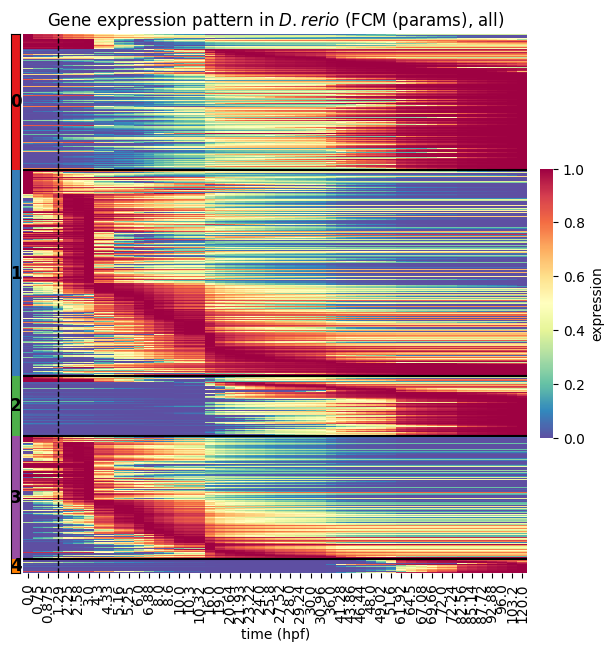

In [144]:
plot_heatmap_supercluster("clustering/joint_simulation_results.nc", cluster_col="supercluster", algo="FCM (params)", norm="minmax",)

[debug] genes surviving normalisation: 21440 / 21440


C:\Users\mgrho\AppData\Local\Temp\ipykernel_24864\2674745044.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


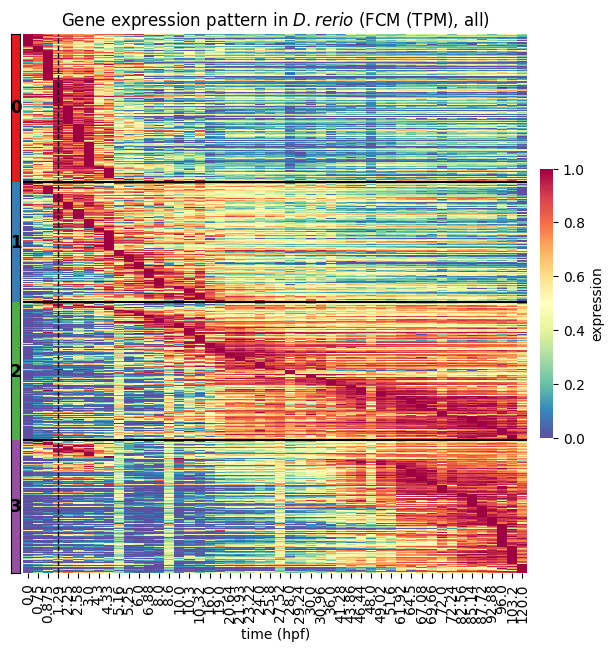

In [145]:
plot_heatmap_supercluster(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc", cluster_col="supercluster", algo="FCM (TPM)", norm="minmax",)

[debug] genes surviving normalisation: 5533 / 5533


C:\Users\mgrho\AppData\Local\Temp\ipykernel_4084\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


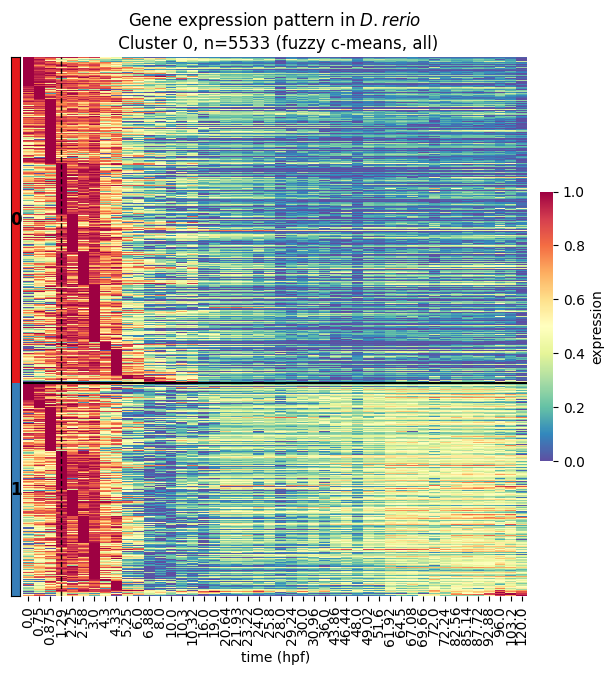

[debug] genes surviving normalisation: 4714 / 4714


C:\Users\mgrho\AppData\Local\Temp\ipykernel_4084\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


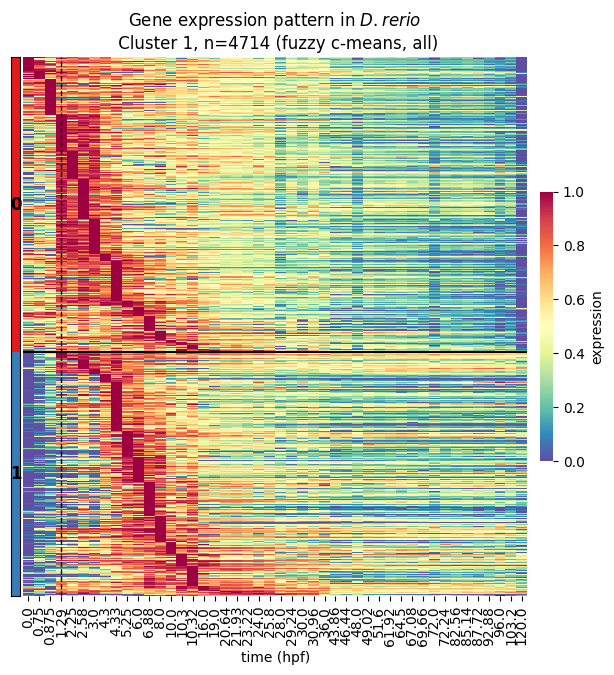

[debug] genes surviving normalisation: 5486 / 5486


C:\Users\mgrho\AppData\Local\Temp\ipykernel_4084\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


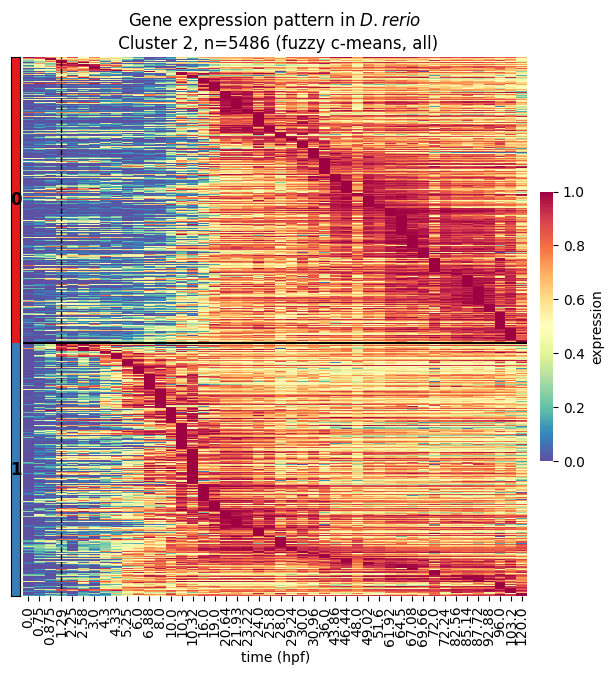

[debug] genes surviving normalisation: 5468 / 5468


C:\Users\mgrho\AppData\Local\Temp\ipykernel_4084\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


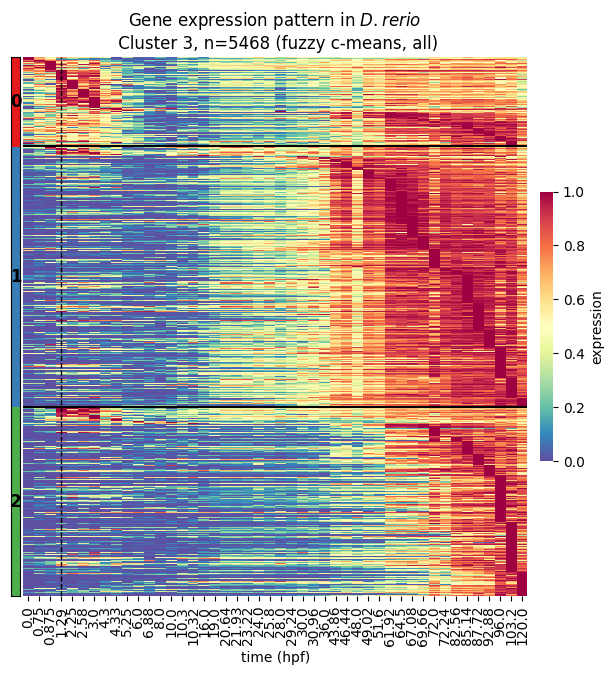

In [ ]:
for i in range(4):
    plot_heatmap_supercluster(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc", cluster_col="subcluster",
                algo="fuzzy c-means", source="all", supercluster=i)

## Model fit Selection by BIC

In [20]:
# load data and combine with supercluster assignment
gof_all = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")
supercluster = xr.load_dataset(f"clustering/results/{sc}_gene_cluster_annotation_minmax.nc")

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": supercluster["ensembl_gene_id"].values,
    "supercluster_no": supercluster["supercluster"].values,
    "subcluster_no": supercluster["subcluster"].values,
}).set_index("ensembl_gene_id")

cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
lookup["supercluster"]=lookup["supercluster_no"].map(cluster_names)

# Map onto df by gene_id
for df in [gof_all, gof_src, params]:
    df["supercluster"] = df["gene_id"].map(lookup["supercluster"])
    df["supercluster_no"] = df["gene_id"].map(lookup["supercluster_no"])
    df["subcluster_no"] = df["gene_id"].map(lookup["subcluster_no"])

gof_all = gof_all[gof_all["gene_id"].isin(genes_acc)]
gof_all

,gene_id,NRMSE,NRMSE_lower,NRMSE_upper,LogLik,LogLik_lower,LogLik_upper,BIC,BIC_lower,BIC_upper,supercluster,supercluster_no,subcluster_no,model
1,ENSDARG00000000002,0.270265,0.176917,0.384435,-33.462400,-36.746632,-30.898830,79.306205,74.179064,85.874666,DSU,3,1,Basic
2,ENSDARG00000000018,0.304176,0.238389,0.386343,-49.140537,-52.698807,-46.312111,110.662477,105.005625,117.779017,DSD,1,1,Basic
3,ENSDARG00000000019,0.213511,0.167638,0.259818,-4.288596,-6.666051,-2.738154,20.958594,17.857712,25.713505,SD,0,1,Basic
5,ENSDARG00000000069,0.133944,0.096092,0.174690,-10.731313,-13.382534,-9.083176,33.844029,30.547754,39.146471,SD,0,0,Basic
10,ENSDARG00000000161,0.251334,0.190167,0.323723,-24.968864,-28.761173,-21.963451,62.319136,56.308306,69.903750,DSU,3,1,Basic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64315,ENSDARG00000117792,0.107091,0.085713,0.128216,19.571558,16.160343,22.261886,-10.253175,-15.633831,-3.430746,SD,0,0,Rep_Z
64316,ENSDARG00000117808,0.144650,0.106684,0.183494,-4.381473,-7.813561,-1.625802,37.652886,32.141545,44.517064,SU,2,1,Rep_Z
64317,ENSDARG00000117812,0.201521,0.161299,0.246682,22.106494,18.217003,24.968481,-15.323046,-21.047021,-7.544066,SU,2,1,Rep_Z
64318,ENSDARG00000117815,0.193380,0.147307,0.242881,-26.658575,-30.168941,-23.932862,82.207090,76.755664,89.227822,SU,2,0,Rep_Z


In [21]:
print(np.percentile(gof_all[gof_all["model"]=="Basic"].BIC, (5,95, 50)))
print(np.percentile(gof_all[gof_all["model"]=="Rep_M"].BIC, (5,95, 50)))
print(np.percentile(gof_all[gof_all["model"]=="Rep_Z"].BIC, (5,95, 50)))

gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")

basic_bic = gof_all[gof_all["model"] == "Basic"].set_index("gene_id")["BIC"]
gof_all["delta_BIC"] = gof_all["BIC"] - gof_all["gene_id"].map(basic_bic)
gof_all[gof_all["delta_BIC"] < -6].value_counts("model") / (gof_all.gene_id.nunique()) *100

# gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
# best_models = gof_all[gof_all["BIC_rank"] == 1]
# best_models.value_counts("model") / (gof_all.gene_id.nunique()) *100

[  0.98180434 181.71495643  93.16641483]
[-21.19922562 138.0395279   58.30191501]
[-20.4791557  134.55748141  54.57089974]


model
Rep_Z    78.095650
Rep_M    71.094909
Name: count, dtype: float64

In [49]:
gof_all[gof_all["BIC_rank"] == 1]

,gene_id,NRMSE,NRMSE_lower,NRMSE_upper,LogLik,LogLik_lower,LogLik_upper,BIC,BIC_lower,BIC_upper,supercluster,supercluster_no,subcluster_no,model,BIC_rank,delta_BIC
5,ENSDARG00000000069,0.133944,0.096092,0.174690,-10.731313,-13.382534,-9.083176,33.844029,30.547754,39.146471,SD,0,0,Basic,1.0,0.000000
18,ENSDARG00000000370,0.287939,0.198199,0.386424,-27.543266,-30.046278,-25.980440,67.467934,64.342283,72.473959,SU,2,1,Basic,1.0,0.000000
23,ENSDARG00000000472,0.300809,0.208576,0.424595,-53.605564,-56.109474,-51.987656,119.592524,116.356714,124.600352,DSU,3,1,Basic,1.0,0.000000
36,ENSDARG00000000666,0.229493,0.167044,0.299527,-28.952337,-31.446669,-27.379517,70.286077,67.140436,75.274740,SU,2,1,Basic,1.0,0.000000
47,ENSDARG00000000853,0.123648,0.079911,0.172710,-12.633401,-15.080071,-11.068664,37.648206,34.518730,42.541546,SD,0,0,Basic,1.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64306,ENSDARG00000117748,0.169880,0.134565,0.209379,24.898723,21.614263,27.473930,-20.907504,-26.057920,-14.338586,SU,2,1,Rep_Z,1.0,-21.141210
64309,ENSDARG00000117777,0.109957,0.077180,0.142819,23.644870,20.496912,25.990583,-18.399799,-23.091226,-12.103883,SD,0,0,Rep_Z,1.0,-12.685692
64310,ENSDARG00000117778,0.127684,0.098406,0.157819,12.930375,8.509710,16.410829,3.029190,-3.931718,11.870520,SD,0,2,Rep_Z,1.0,-122.787217
64315,ENSDARG00000117792,0.107091,0.085713,0.128216,19.571558,16.160343,22.261886,-10.253175,-15.633831,-3.430746,SD,0,0,Rep_Z,1.0,-39.091625


In [48]:
## prefered gene-wise
gof_all[gof_all["BIC_rank"] == 1].groupby("model").gene_id.count() / gof_all.gene_id.nunique() * 100

model
Basic    13.012852
Rep_M    34.466139
Rep_Z    52.521008
Name: gene_id, dtype: float64

In [42]:
gof_all[["gene_id", "model","BIC", "delta_BIC", "BIC_rank"]]

,gene_id,model,BIC,delta_BIC,BIC_rank
1,ENSDARG00000000002,Basic,79.306205,0.000000,2.0
2,ENSDARG00000000018,Basic,110.662477,0.000000,3.0
3,ENSDARG00000000019,Basic,20.958594,0.000000,3.0
5,ENSDARG00000000069,Basic,33.844029,0.000000,1.0
10,ENSDARG00000000161,Basic,62.319136,0.000000,3.0
...,...,...,...,...,...
64315,ENSDARG00000117792,Rep_Z,-10.253175,-39.091625,1.0
64316,ENSDARG00000117808,Rep_Z,37.652886,-2.509750,2.0
64317,ENSDARG00000117812,Rep_Z,-15.323046,-9.286224,1.0
64318,ENSDARG00000117815,Rep_Z,82.207090,-33.823862,2.0


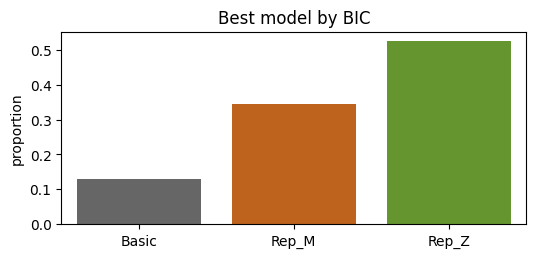

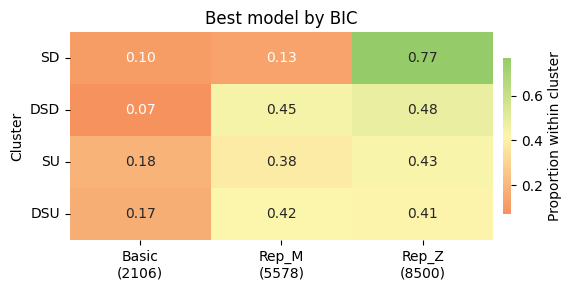

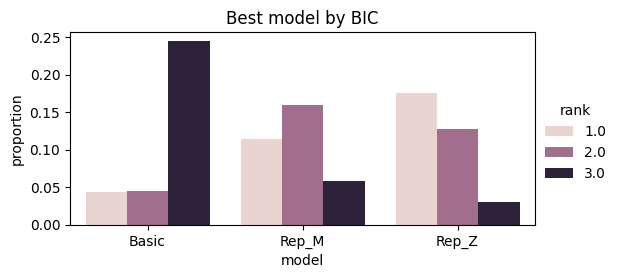

In [52]:
metr = "BIC"
best_models = gof_all.loc[gof_all.groupby("gene_id")[metr].idxmin()]
cluster_counts = pd.crosstab(best_models["model"], best_models["supercluster"])
counts = cluster_counts[["SD", "DSD", "SU", "DSU"]].T
prop =  cluster_counts[["SD", "DSD", "SU", "DSU"]] / cluster_counts[["SD", "DSD", "SU", "DSU"]].sum()
prop = prop.T

labels = [f"{i}\n({counts[i].sum()})" for i in counts.columns]

fig = plt.figure(figsize=(6,2.5))
sns.countplot(best_models, x="model", hue="model",palette=mod_color_dict, order=model_order, stat="proportion")
plt.title(f"Best model by {metr}")
plt.xlabel("")
plt.savefig(f"results/figures/best_by_{metr}.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
sns.heatmap(prop, annot=True, fmt=".2f", cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': 'Proportion within cluster', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)

ax.set(xlabel="", title=f"Best model by {metr}", ylabel="Cluster")
plt.yticks(rotation=0)
ax.set_xticklabels(labels)
plt.tight_layout()
plt.savefig(f"results/figures/best_by_{metr}_cluster.png", dpi=300)
plt.show()

#best_models = gof_all.loc[gof_all.groupby("gene_id")["BIC"].idxmin()]
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
best_models = gof_all[gof_all["BIC_rank"] == 1]

fig = plt.figure(figsize=(6,2.5))
sns.countplot(gof_all, x="model", hue="BIC_rank", stat="proportion")
plt.title("Best model by BIC")
plt.legend(loc=(1.01, 0.2), frameon=False, title="rank")
plt.savefig("results/figures/best_by_bic_rank.png", dpi=300)
plt.show()

### Evaluate early stages by BIC

In [104]:
params_selected = xr.load_dataset("clustering/joint_params_results.nc")
traj_selected = xr.load_dataset("clustering/joint_simulation_results.nc")
gof = pd.read_csv("clustering/prefered_decay_mode.csv",).rename(columns={"ensembl_gene_id":"gene_id"})
ds_params = pd.read_csv("results/results_summary/params_combined.csv")

model_map = {"Z": "Rep_Z", "M": "Rep_M"}
gof_sel = ( gof[["gene_id", "decay_mode", "significant", "dBIC"]].copy().assign(model=lambda d: d["decay_mode"].map(model_map)))
ds_params_selected = ( ds_params.merge(gof_sel, how="inner", on=["gene_id", "model"] ))
ds_params_selected.decay_mode.value_counts()
ds_params_selected.head()

,gene_id,beta_mean,delta_mean,sigma_y_mean,beta_std,delta_std,sigma_y_std,supercluster,supercluster_no,subcluster_no,...,t_rep_mean,t_zga_mean,alpha_std,delta_m_std,t_reg_std,t_rep_std,t_zga_std,decay_mode,significant,dBIC
0,ENSDARG00000000002,1.20,NaN,0.360,0.136,NaN,0.0348,DSU,3,1,...,34.10,12.500,0.0817,0.0428,7.590,7.530,1.550,M,False,4.814891
1,ENSDARG00000000069,8.38,NaN,0.278,0.590,NaN,0.0276,SD,0,0,...,19.30,3.060,9.5300,0.0505,7.650,7.950,1.600,M,True,49.195928
2,ENSDARG00000000380,1.04,NaN,0.406,0.159,NaN,0.0387,DSU,3,2,...,63.40,1.390,0.0188,0.5500,2.380,2.510,0.812,M,False,4.342291
3,ENSDARG00000000394,5.04,NaN,0.196,0.249,NaN,0.0187,DSD,1,1,...,5.80,0.556,6.7500,0.0716,0.839,0.944,0.259,M,False,1.632351
4,ENSDARG00000000489,1.90,NaN,0.282,0.275,NaN,0.0276,DSD,1,1,...,4.33,0.914,3.4600,0.1000,4.390,4.450,0.399,M,False,0.059996


In [106]:
## SD cluster
gof_cluster = ds_params_selected[ds_params_selected["supercluster"] == "SD"].copy()
print("genes in SD cluster",len(gof_cluster))
print(gof_cluster.decay_mode.value_counts() / len(gof_cluster))
print(gof_cluster.significant.value_counts() / len(gof_cluster))

gof_cluster.groupby(["decay_mode","significant"]).count()["gene_id"]


genes in SD cluster 4880
decay_mode
Z    0.83873
M    0.16127
Name: count, dtype: float64
significant
True     0.872746
False    0.127254
Name: count, dtype: float64


decay_mode  significant
M           False           106
            True            681
Z           False           515
            True           3578
Name: gene_id, dtype: int64

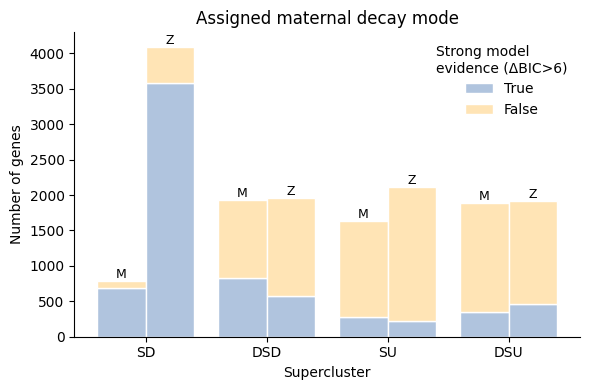

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# counts per supercluster, decay_mode, significant
summ = (
    ds_params_selected
    .groupby(["supercluster", "decay_mode", "significant"])
    .size()
    .reset_index(name="n_genes")
)


superclusters = cluster_order
decay_modes = sorted(summ["decay_mode"].unique())
sig_values = [True, False]  # stack order: bottom -> top

x = np.arange(len(superclusters))
width = 0.8 / len(decay_modes)

fig, ax = plt.subplots(figsize=(6, 4))

colors = {True: "lightsteelblue", False: "moccasin"}

for i, dm in enumerate(decay_modes):
    bottom = np.zeros(len(superclusters))
    offset = (i - (len(decay_modes) - 1) / 2) * width

    for sig in sig_values:
        vals = []
        for supc in superclusters:
            match = summ[
                (summ["supercluster"] == supc)
                & (summ["decay_mode"] == dm)
                & (summ["significant"] == sig)
            ]
            vals.append(match["n_genes"].values[0] if len(match) else 0)
        vals = np.array(vals)

        ax.bar(
            x + offset, vals, width,
            bottom=bottom,
            color=colors[sig],
            label=f"{sig}" if i == 0 else None,  # avoid duplicate legend entries
            edgecolor="white",
        )
        bottom += vals

# place decay_mode label on top of each stacked bar
    for xi, total in zip(x, bottom):
        ax.text(
            xi + offset, total + max(bottom) * 0.0, dm,
            ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(superclusters)
ax.set_xlabel("Supercluster")
ax.set_ylabel("Number of genes")
ax.set_title("Assigned maternal decay mode")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Strong model\nevidence (ΔBIC>6)", frameon=False)
plt.tight_layout()
plt.savefig("figures/decay_modes_by_cluster.png")
plt.show()

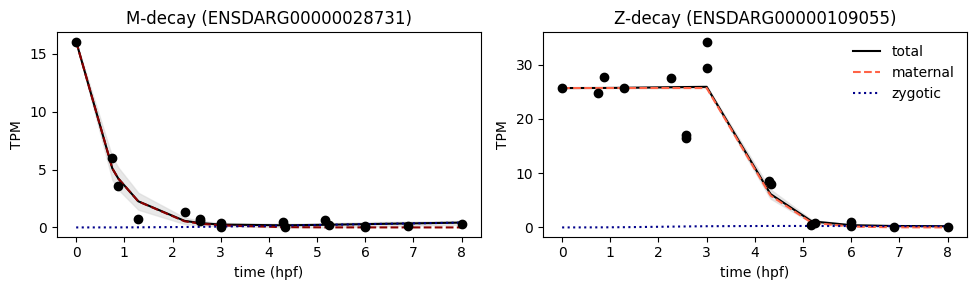

In [20]:
ds_params_selected[ds_params_selected["decay_mode"] == "Z"].sort_values("dBIC")[["gene_id", "dBIC"]]
# best M: ENSDARG00000028731
# best Z: ENSDARG00000109055

import matplotlib.pyplot as plt
import xarray as xr
import arviz as az

m0 = az.from_netcdf("results/ENSDARG00000028731/numpyro_posterior.nc").sel(time=slice(0,8))
hdi_m = az.hdi(m0.posterior_model_fits.mean(dim="source"), 0.95).y
m = m0.posterior_model_fits.mean(dim=("chain", "draw", "source"))
z0 = az.from_netcdf("results/ENSDARG00000109055/numpyro_posterior.nc").sel(time=slice(0,8))
hdi_z = az.hdi(z0.posterior_model_fits.mean(dim="source"), 0.95).y
z = z0.posterior_model_fits.mean(dim=("chain", "draw", "source"))
#m = az.from_netcdf("../evaluation/8hpf/M-decay/ENSDARG00000069545/numpyro_posterior.nc").posterior_model_fits.mean(dim=("chain", "draw"))
#z = az.from_netcdf("../evaluation/8hpf/Z-decay/ENSDARG00000015657/numpyro_posterior.nc").posterior_model_fits.mean(dim=("chain", "draw"))
ds_m = m0.observed_data
ds_z = z0.observed_data

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3))
ax1.plot(m.time, m.y, "k", label="total",)
ax1.plot(m.time, m.M, "--", label="maternal", c="darkred")
ax1.plot(m.time, m.Z,  ":", label="zygotic", c="darkblue")
ax1.fill_between(hdi_m.time, *hdi_m.values.T, color="lightgrey", alpha=0.5)
ax1.plot(ds_m.time, ds_m.y, "ko")
ax1.set(title="M-decay (ENSDARG00000028731)", xlabel="time (hpf)", ylabel="TPM")

ax2.plot(z.time, z.y, "k",label="total")
ax2.plot(z.time, z.M, "--", label="maternal",  c="tomato")
ax2.plot(z.time, z.Z,  ":", label="zygotic",  c="darkblue")
ax2.fill_between(hdi_z.time,  *hdi_z.values.T, color="lightgrey", alpha=0.5)
ax2.plot(ds_z.time, ds_z.y, "ko")
ax2.set(title="Z-decay (ENSDARG00000109055)", xlabel="time (hpf)", ylabel="TPM")
ax2.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/decay_modes_fit.png")

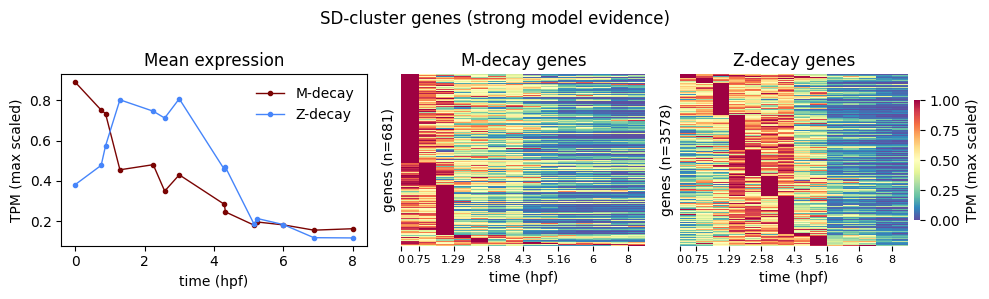

In [28]:
import seaborn as sns
import xarray as xr
from matplotlib import colormaps
import matplotlib.pyplot as plt

clstr = "SD"
gof_cluster = ds_params_selected[ds_params_selected["supercluster"] == clstr].copy()

colors = colormaps['turbo'].resampled(7)

zgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "Z")].gene_id.values
mgenes = gof_cluster.loc[(gof_cluster["significant"] == True) & (gof_cluster["decay_mode"] == "M")].gene_id.values

ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0,8)).mean(dim="source")
dm = ds.sel(ensembl_gene_id = mgenes)
dz = ds.sel(ensembl_gene_id = zgenes)

ds = dm / dm.max("time") # max scaled
dz = dz / dz.max("time") # max scaled

# Find time index of max expression for each gene
argmax_time_idx = ds.tpm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
ds = ds.isel(ensembl_gene_id=sort_idx)

# Find time index of max expression for each gene
argmax_time_idx = dz.tpm.argmax(dim="time").values
sort_idx = np.argsort(argmax_time_idx)
dz = dz.isel(ensembl_gene_id=sort_idx)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10, 3), width_ratios=(1, 0.8, 0.9))

ax1.plot(ds.time, ds.tpm.mean(dim="ensembl_gene_id"), c=colors(6), lw=1, label="M-decay", marker=".", )
ax1.plot(dz.time, dz.tpm.mean(dim="ensembl_gene_id"), c=colors(1), lw=1, label="Z-decay", marker=".", )
ax1.set(title="Mean expression", xlabel='time (hpf)', ylabel="TPM (max scaled)")
ax1.legend(frameon=False)

hm = sns.heatmap(ds.tpm.T, 
            xticklabels=ds['time'].values,
            yticklabels=ds['ensembl_gene_id'].values,
            ax = ax2,
            cmap='Spectral_r', square=False,
            cbar=False,
            #cbar_kws={'label': 'TPM (max scaled)','shrink': 0.7, 'pad': 0.02 }
            )
ax2.set(title="M-decay genes", xlabel='time (hpf)',  ylabel=f"genes (n={len(ds.ensembl_gene_id)})"     )
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=9)

hm = sns.heatmap(dz.tpm.T, 
            xticklabels=dz['time'].values,
            yticklabels=dz['ensembl_gene_id'].values,
            ax = ax3,
            cmap='Spectral_r', square=False,
            cbar_kws={'label': 'TPM (max scaled)','shrink': 0.7, 'pad': 0.02 })
ax3.set(title="Z-decay genes", xlabel='time (hpf)',  ylabel=f"genes (n={len(dz.ensembl_gene_id)})"     )
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, fontsize=9)

# Keep only a readable subset of time labels on both heatmaps.
xtick_idx = np.linspace(0, len(ds.time) - 1, 8, dtype=int)
xtick_labels = [f"{ds.time.values[i]:g}" for i in xtick_idx]

ax2.set_xticks(xtick_idx)
ax2.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
ax3.set_xticks(xtick_idx)
ax3.set_xticklabels(xtick_labels, rotation=0, fontsize=8)

ax2.set_yticks([])
ax3.set_yticks([])
plt.suptitle(f"{clstr}-cluster genes (strong model evidence)")
#plt.suptitle("SD-cluster genes (weak model evidence)")
plt.tight_layout()
plt.savefig(f"figures/strong_model_evidence_{clstr}.png")
#plt.savefig("figures/weak_model_evidence.png")

plt.show()

## load reduced dataset


In [119]:
params_selected = xr.load_dataset("clustering/joint_params_results.nc")
traj_selected = xr.load_dataset("clustering/joint_simulation_results.nc")
gof = pd.read_csv("clustering/prefered_decay_mode.csv",).rename(columns={"ensembl_gene_id":"gene_id"})
ds_params = pd.read_csv("results/results_summary/params_combined.csv")

model_map = {"Z": "Rep_Z", "M": "Rep_M"}
gof_sel = ( gof[["gene_id", "decay_mode"]].copy().assign(model=lambda d: d["decay_mode"].map(model_map)))
ds_params_selected = ( ds_params.merge(gof_sel, how="inner", on=["gene_id", "model"] ))
ds_params_selected.decay_mode.value_counts()

decay_mode
Z    10084
M     6242
Name: count, dtype: int64

## Parameter-cluster scatterplot

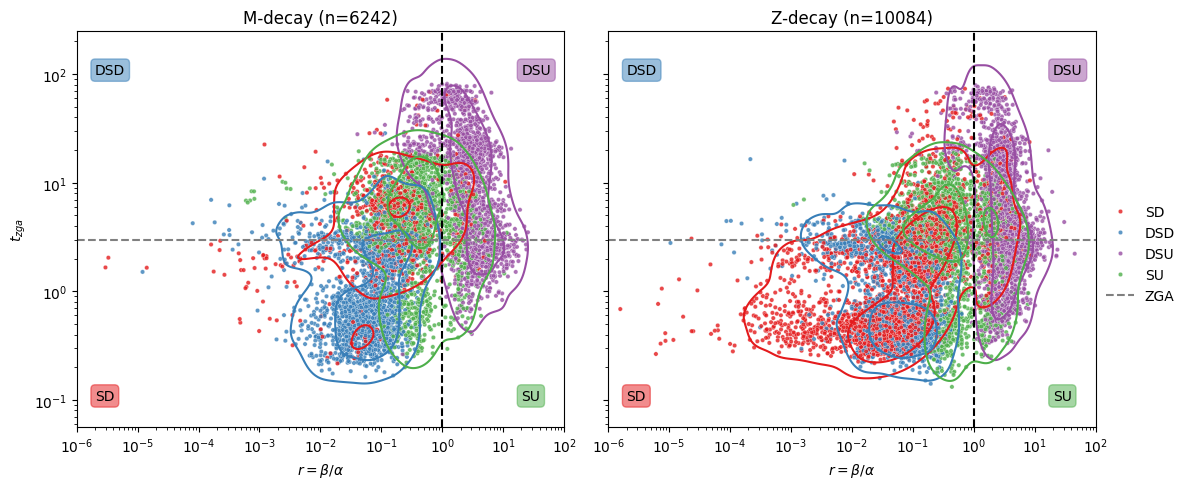

In [109]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

#params = pd.read_csv("results/results_summary/params_combined.csv")
params =  ds_params_selected.copy()

df = params[params["model"] != "Basic"].copy()
df["beta_mean"] = df["beta_mean"].clip(lower=1e-5)
df["alpha_mean"] = df["alpha_mean"].clip(lower=1e-5)
df["t_zga_mean"] = df["t_zga_mean"].clip(upper=120)

df["r"] = df["beta_mean"] / df["alpha_mean"]
#df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(df_m, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", s=10, palette=cluster_color_dict, alpha=0.8, legend=False)
sns.scatterplot(df_z, x="r", y="t_zga_mean", ax=ax2, hue="supercluster", s=10, palette=cluster_color_dict, alpha=0.8, legend=True)

sns.kdeplot(df_m, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=3)
sns.kdeplot(df_z, x="r",  y="t_zga_mean", hue="supercluster", ax=ax2, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=3)

ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title=f"M-decay (n={len(df_m)})", xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax2.set(xlabel="$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title=f"Z-decay (n={len(df_z)})", xscale="log", yscale="log", xlim=(1e-6, 1e2), )

ax1.axvline(1, c="k", ls="--")
ax2.axvline(1, c="k", ls="--")
ax1.axhline(3, c="gray", ls="--", label="ZGA")
ax2.axhline(3, c="gray", ls="--", label="ZGA")
#ax1.axhline(1, c="gray", ls="-.", label="ZGA")
#ax2.axhline(1, c="gray", ls="-.", label="ZGA")

ax1.text(x=2e-6, y=100, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e-6, y=0.1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=100, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=0.1,s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax2.text(x=2e-6, y=100, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e-6, y=0.1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=100, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=0.1, s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

#ax1.legend(loc=(0.1,0.7),frameon=False)
ax2.legend(loc=(1.01,0.3),frameon=False)
plt.tight_layout()
plt.savefig("results/figures/scatter_params_cluster_tzga.png", dpi=300)
plt.show()

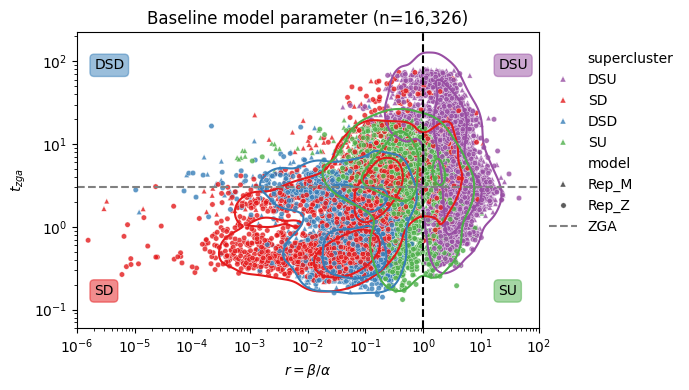

In [114]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

params =  ds_params_selected.copy()

df = params[params["model"] != "Basic"].copy()
df["beta_mean"] = df["beta_mean"].clip(lower=1e-5)
df["alpha_mean"] = df["alpha_mean"].clip(lower=1e-5)
df["t_zga_mean"] = df["t_zga_mean"].clip(upper=120)

df["r"] = df["beta_mean"] / df["alpha_mean"]



fig, (ax1) = plt.subplots(1,1, figsize=(7,4), sharex=True, sharey=True)
sns.scatterplot(df, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", style="model", markers={"Rep_M":"^", "Rep_Z":"o"}, s=15, palette=cluster_color_dict, alpha=0.8, legend=True)
sns.kdeplot(df, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=False, log_scale=True, fill=False, levels=3)
ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title=f"Baseline model parameter (n={len(df):,})", xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax1.axvline(1, c="k", ls="--")
ax1.axhline(3, c="gray", ls="--", label="ZGA")

ax1.text(x=2e-6, y=80, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e-6, y=0.15, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=80, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=0.15,s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax1.legend(loc=(1.01,0.3),frameon=False)
plt.tight_layout()
plt.savefig("results/figures/scatter_params_cluster_tzga_joint.png", dpi=300)
plt.show()

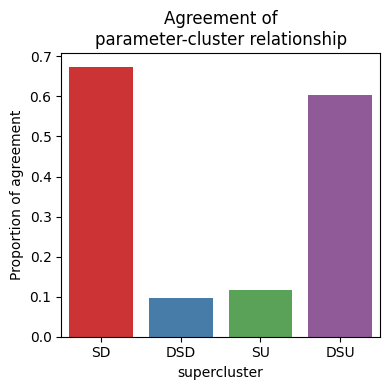

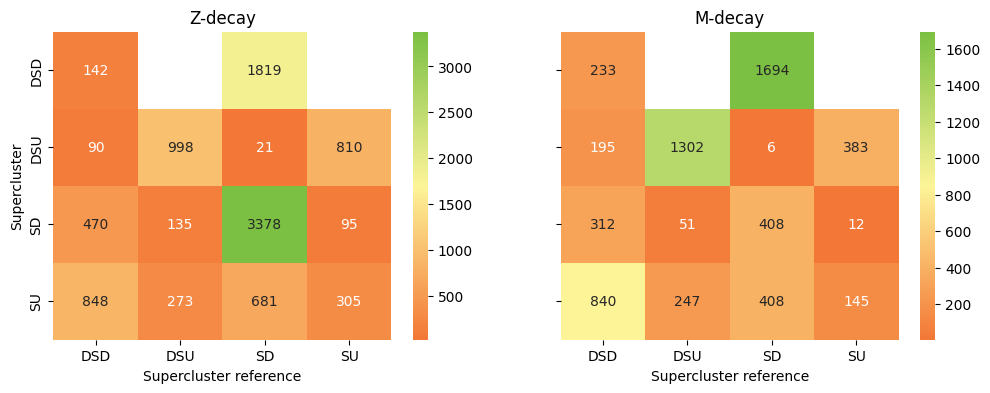

In [130]:
# ds_params = pd.read_csv("results/results_summary/params_combined.csv")
# df = ds_params[ds_params["model"] != "Basic" ].copy()

df = ds_params_selected.copy()

df["r"] = df["beta_mean"] / df["alpha_mean"]
df["t_half_m"] = np.log(2) / df["delta_m_mean"]
df = df[df["r"] > 1e-5]
param_cluster = df[["gene_id", "model", "r", "t_zga_mean", "t_rep_mean", "supercluster"]].copy()

import numpy as np

zga_time = 3.0

param_cluster["t_zga"] = np.minimum(param_cluster["t_zga_mean"],  param_cluster["t_rep_mean"])
param_cluster["t_reg"] = np.maximum(param_cluster["t_zga_mean"],  param_cluster["t_rep_mean"])

param_cluster.loc[param_cluster["r"] > 1, "dir"] = "up"
param_cluster.loc[param_cluster["r"] == 1, "dir"] = "none"
param_cluster.loc[param_cluster["r"] < 1, "dir"] = "down"

param_cluster.loc[param_cluster["t_zga"] < zga_time, "activation"] = "early"
#param_cluster.loc[(param_cluster["t_zga"] <= 4) & (param_cluster["t_zga"] >= 2) , "activation"] = "zga"
param_cluster.loc[param_cluster["t_zga"] >= zga_time, "activation"] = "late"

param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["activation"] == "early"), "cluster_ref"] = "SU"
param_cluster.loc[(param_cluster["dir"] == "up") &  (param_cluster["activation"] == "late"), "cluster_ref"] = "DSU"
param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["activation"] == "early"), "cluster_ref"] = "SD"
param_cluster.loc[(param_cluster["dir"] == "down") &  (param_cluster["activation"] == "late"), "cluster_ref"] = "DSD"

param_cluster["agree"] = False
param_cluster.loc[param_cluster["supercluster"] ==  param_cluster["cluster_ref"], "agree"] = True

#param_cluster.loc[param_cluster["t_reg_mean"] < 2, "activation"] = "early"
#param_cluster.loc[(param_cluster["t_reg_mean"] <= 4) & (param_cluster["t_zga_mean"] >= 2) , "activation"] = "zga"
#param_cluster.loc[param_cluster["t_reg_mean"] > 4, "activation"] = "late"

import seaborn as sns
import matplotlib.pyplot as plt

res = param_cluster.groupby(["model", "supercluster"])["agree"].mean()
res_df = res.reset_index()
# columns: model, supercluster, agree

plt.figure(figsize=(4, 4))
#sns.barplot(data=res_df, x="supercluster", y="agree", hue="model", palette=mod_color_dict)
sns.barplot(data=res_df, x="supercluster", y="agree", errorbar=None, hue="supercluster", palette=cluster_color_dict, order=cluster_order)

plt.ylabel("Proportion of agreement")
plt.title("Agreement of\nparameter-cluster relationship")
#plt.legend(title="Model", frameon=False)
plt.tight_layout()
plt.savefig("clustering/figs/simple_parameter_cluster_relationship.png", dpi=300)
plt.show()


param_cluster1 = param_cluster[param_cluster["model"] == "Rep_Z"]
res_df = param_cluster1.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()

df_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")
import seaborn as sns
cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)

fig, ax = plt.subplots(1,2, figsize=(12, 4), sharey= True)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[0])
ax[0].set(title="Z-decay",ylabel="Supercluster",xlabel="Supercluster reference")
# Z-decay
param_cluster2 = param_cluster[param_cluster["model"] == "Rep_M"]
res_df = param_cluster2.groupby(["cluster_ref", "supercluster"])["agree"].count().reset_index()

df_plot = res_df.pivot(index="supercluster", columns="cluster_ref", values="agree")
cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax[1])
ax[1].set(title="M-decay",ylabel="",xlabel="Supercluster reference")
plt.savefig("clustering/figs/simple_parameter_cluster_relationship_MZdecay.png", dpi=300)
plt.show()

### Test metrics

pearson 0.9879131117731396
spearman 0.9245138055222089


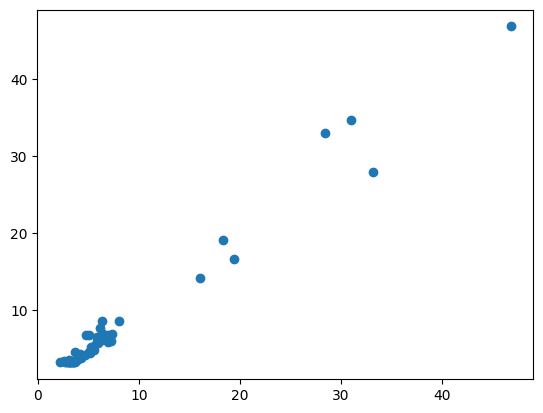

In [ ]:
from reports import report
import arviz as az
import numpy as np
from scipy.stats import spearmanr, pearsonr
idata = az.from_netcdf("results/ENSDARG00000000069/numpyro_posterior.nc")
#idata = az.from_netcdf("results/ENSDARG00000000212/numpyro_posterior.nc")
#idata = az.from_netcdf("results/ENSDARG00000001057/numpyro_posterior.nc") #ENSDARG00000012572
idata = az.from_netcdf("results/ENSDARG00000012572/numpyro_posterior.nc")

obs = idata.observed_data.y.mean(dim=("source"))
pred =idata.posterior_model_fits.y.mean(dim=("chain", "draw", "source"))
plt.scatter(obs, pred)

print("pearson", pearsonr(obs, pred)[0])
print("spearman", spearmanr(obs, pred)[0])

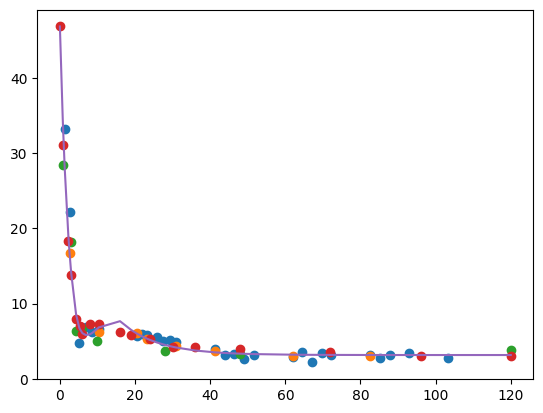

In [ ]:
plt.plot(obs.time, obs, "o")
plt.plot(pred.time, pred)

In [ ]:
obs = idata.observed_data.y.mean(dim="source")
pred = idata.posterior_model_fits.y.mean(dim=("chain", "draw", "source"))
rho = spearmanr(obs, pred, nan_policy="omit")[0]
print(rho.item())

ss_res = ((obs - pred) ** 2).sum()
ss_tot = ((obs - obs.mean()) ** 2).sum()
r2_per_source = 1 - ss_res / ss_tot
r2 = r2_per_source.where(ss_tot > 0)
print(r2.item())

0.9245138055222089
0.9755073825998287
